In [14]:
suppressPackageStartupMessages(library(dplyr)) 
library(ggplot2)
library(pheatmap)
library(RColorBrewer)
library(Seurat)
library(harmony)
library(repr)
suppressPackageStartupMessages(library(GenomicRanges))

source("/projects/ps-renlab2/y2xie/scripts/basics.R")
source("/projects/ps-renlab2/y2xie/scripts/DPT_help.R")

In [2]:
sum_detailed_anno <- function(df){
    t1 <- table(df$Detailed.Annotation) %>% as.data.frame %>%
    mutate(Var1 = gsub("^([^\\(]+).*", "\\1", Var1)) %>%
    group_by(Var1) %>% summarise(Freq = sum(Freq))

    t1a1 <- t1[grep("\\|", t1$Var1, invert = T), ] %>%
    mutate(Var1 = gsub("^(CpG)-.*$", "\\1", Var1)) %>%
    group_by(Var1) %>% summarise(Freq = sum(Freq)) %>% setNames(c("Var1", "Freq"))

    t1a2 <- t1[grep("\\|", t1$Var1), ] %>% 
    mutate(Var1 = gsub("^([^|]+)\\|([^|]+)\\|([^|]+)$", "\\2", Var1)) %>%
    mutate(Var1 = gsub("\\?", "", Var1)) %>%
    mutate(simple = ifelse(Var1 %in% c("LINE", "LTR", "SINE", "Simple_repeat"), Var1, "Other repeats")) %>%
    group_by(simple) %>% summarise(Freq = sum(Freq)) %>% setNames(c("Var1", "Freq"))

    anno <- rbind(t1a1, t1a2)
    return(anno)
}

In [3]:
## read donor disease info
donor_info <- read.csv("../reference/FNIH_Livers_donorinfo_updated_240906.csv", header = T)
length(unique(donor_info[,1]))

[1] 119

In [4]:
### set color
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

cellsubtype_colors <- c(
  NK = "#6A0DAD",                         
  T = "#9B59B6",                          
  Sinusoidal.Endothelial = "#CF1B14",     
  Lymphatic.Endothelial = "#FFCBC2",      
  Central.Vein.Endothelial = "#F27C78",   
  Vascular.Endothelial = "#8E0B0B",       
  Kupffer = "#B04202",                    
  Macrophage = "#F5AD75",                 
  Lipid.Associated.Macrophage = "#FF7105",
  B = "#9E239A",                          
  Plasma = "#E995E7",                     
  Cholangiocyte = "#E1AD01",              
  Quescent.HSC = "#4682B4",               
  Activated.HSC = "#1E90FF",              
  Mesenchymal = "#004F9E",                
  Mast = "#FD7BB8",                       
  Schwann = "#81CDC6",                    
  Hepatocytes.Zone1 = "#006D2C",          
  Hepatocytes.Zone2 = "#4DAF4A",          
  Hepatocytes.Zone3 = "#9ED69F",          
  Hepatocytes.Senescent = "#AED96A",      
  Hepatocytes.Stress = "#526E12"          
)

cols <- c("#c0c0c0", "#cd5c5c","#008000", "#ffc800", '#66cdaa')
names(cols) <- c("E1", "E2", "E3", "E4", "E5")

corder <- c("T", "NK", "B", "Mast", "Myeloid", "Hepatocytes", "Cholangiocyte", "Schwann", 'HSC', "Endothelial")

In [7]:
meta <- read.csv("../../92.FNIH_DHC_IGM_241121/05.R/integration/All_data.int.csv", row.names = 1)
head(meta)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_RNA_raw,nFeature_RNA_raw,donor_demux,nCount_SCT,nFeature_SCT,SCT.weight,⋯,trans,log_umi,predicted.id,predicted.score,X,condition2,integrated_subtype,integrated_majortype,nn2.cellsubtype,tech
,<chr>,<dbl>,<int>,<dbl>,<int>,<int>,<chr>,<int>,<int>,<dbl>,⋯,<int>,<dbl>,<chr>,<dbl>,<int>,<chr>,<int>,<int>,<chr>,<chr>
MM_1341_1_2_MM_1337_1_2_AAACAGCCACAGACTC-1,MULTIOME,1629,1173,0.06138735,1644,1185,HL160042,3778,1405,0.4101630,⋯,NA,NA,NA,NA,NA,NA,1,1,Sinusoidal.Endothelial,ATAC
MM_1341_1_2_MM_1337_1_2_AAACAGCCAGTTATGT-1,MULTIOME,9791,3730,0.00000000,10043,3858,HL170046,5944,3371,0.6005030,⋯,NA,NA,NA,NA,NA,NA,1,1,Hepatocytes.Zone2,ATAC
MM_1341_1_2_MM_1337_1_2_AAACAGCCATCGTTCT-1,MULTIOME,3222,1911,0.06207325,3270,1938,HL190326,4509,1891,0.6803172,⋯,NA,NA,NA,NA,NA,NA,1,1,Hepatocytes.Zone3,ATAC
MM_1341_1_2_MM_1337_1_2_AAACAGCCATGGCCTG-1,MULTIOME,2806,1670,0.03563792,2844,1689,HL160029,4474,1659,0.5316383,⋯,NA,NA,NA,NA,NA,NA,1,1,Sinusoidal.Endothelial,ATAC
MM_1341_1_2_MM_1337_1_2_AAACAGCCATGTTGGC-1,MULTIOME,6370,2897,0.00000000,6506,2984,HL170060,5716,2869,0.4956006,⋯,NA,NA,NA,NA,NA,NA,1,1,Hepatocytes.Zone3,ATAC
MM_1341_1_2_MM_1337_1_2_AAACAGCCATTGACAT-1,MULTIOME,2351,1399,0.63802637,2382,1420,HL190326,4296,1400,0.4492367,⋯,NA,NA,NA,NA,NA,NA,1,1,Vascular.Endothelial,ATAC


## Prepare results for ABC links

In [291]:
### for cell type
k27ac <- read.csv("FNIH_DPT_signal/FNIH_Liver_pool.H3K27ac.LiverUnionPeaks.cpm.csv", row.names = 1) ### FNIH
for (f in colnames(k27ac)){
    tmp <- k27ac[, f, drop = F]
    tmp[,c("chr", "start", "end")] <- stringr::str_split_fixed(rownames(tmp), pattern = "[:-]", n = 3)
    write.table(tmp[,c("chr", "start", "end", f)], paste0("../../92.FNIH_DHC_IGM_241121/05.R/abc/celltype/", f, "_H3K27ac.cpm"),
                row.names = F, col.names = F, sep = "\t", quote = F)
}

In [100]:
### RNA expression with annotation
### FNIH all
### "chr", "start", "end", "name" "signal" "strand"
rpkm <- read.table("integration/FNIH_Liver_pool.int.rpkm.txt", row.names = 1, header = T, sep = "\t")
hg38 <- read.table("/projects//ps-renlab/y2xie/projects/genome_ref/Paired-Tag/hg38/hg38.gcode.10X.bed")
for (f in colnames(rpkm)){
    tmp <- merge(hg38, rpkm, by.x = "V6", by.y = 0) %>% select(c(V1, V2, V3, V6, all_of(f), V4))
    tmp$V6 <- make.unique(tmp$V6, sep = "..") ### prevent gene name duplication and we can rescue later
    write.table(tmp, paste0("../../92.FNIH_DHC_IGM_241121/05.R/abc//celltype/", f, "_gex.rpkm"),
                row.names = F, col.names = F, sep = "\t", quote = F)
}


### Read abc links

In [13]:
abc <- list()
for (f in unique(colnames(k27ac))){
    tmp <- read.table(paste0("../../92.FNIH_DHC_IGM_241121//05.R/abc/celltype/output/", f, "/EnhancerPredictions.txt"), sep = "\t", header = T) 
    # %>% filter(abs(((start+end)/2) - TargetGeneTSS) >= 30000) ### long range only
    gex <- read.table(paste0("../../92.FNIH_DHC_IGM_241121/05.R/abc/celltype/", f, "_gex.rpkm"), header = F, sep = "\t")
    ac <- read.table(paste0("../../92.FNIH_DHC_IGM_241121/05.R/abc/celltype/", f, "_H3K27ac.cpm"), header = F, sep = "\t")
    gex <- gex %>%
    mutate(start = ifelse(V6 == "+", V2, V3-1)) %>%
    mutate(end = ifelse(V6 == "+", V2+1, V3)) %>%
    select(c(V1, start, end, V4, V5)) %>% setNames(c("chrom", "start", "end", "TargetGene", "RPKM"))
    tmp <- tmp %>% mutate(range = paste0(chr, ":", start, "-", end))
    ac <- ac %>% setNames(c("chrom", "start", "end", "CPM")) %>% mutate(range = paste0(chrom, ":", start, "-", end))
    
    tmp$CellType <- f
    tmp <- merge(tmp, gex, by = "TargetGene")
    abc[[f]] <- merge(tmp, ac, by = "range") %>% select(c(chr, start.x, end.x,range, name, CPM, chrom.x, start.y, end.y, TargetGene, RPKM, CellType, ABC.Score))
    
}
abc <- do.call(rbind, abc)

In [19]:
abc <- read.table("../../92.FNIH_DHC_IGM_241121/05.R/abc/FNIH_liver_celltype_abc_links.txt", header = T)
gts <- abc[,c(1:3,7:9,4,10,5,12,13)] %>%
setNames(c("chrom1", "start1", "end1", "chrom2", "start2", "end2", "peak", "gene", "pair", "celltype", "abc_score"))

write.table(gts, "../../92.FNIH_DHC_IGM_241121/05.R/abc/FNIH_liver_celltype_abc_links.txt", sep = "\t", quote = F, row.names = F, col.names = T)

table(gts$celltype)


            B Cholangiocyte   Endothelial   Hepatocytes           HSC 
         4734          4080          2561          5502          2031 
         Mast       Myeloid            NK       Schwann             T 
         9196          5668          6837          2590          6957 

## Plot marker genes

In [21]:
### Gene from WE
rmarker <- read.table("../reference/Liver_Marker_Gene.txt", sep = " ", header = T) %>%
group_by(CellType) %>% slice_sample(n = 2) %>% ungroup()
rmarker <- rmarker %>% arrange(CellType) 

In [45]:
### Plot targeting enhancer
abc <- read.table("../../92.FNIH_DHC_IGM_241121/05.R/abc/FNIH_liver_celltype_abc_links.txt", header = T)
intersect(abc$gene, rmarker$marker) %>% length
length(rmarker$marker)

[1] 24

[1] 40

In [179]:
system("mkdir ../../92.FNIH_DHC_IGM_241121/05.R/abc/Hepatocytes/")
abc <- read.table("../../92.FNIH_DHC_IGM_241121/05.R/abc/FNIH_liver_disease_abc_links.txt", header = T)
qabc <- abc %>% filter(celltype %in% grep("Hepatocytes", unique(abc$celltype), value = T)) 
for (f in unique(qabc$celltype)){
    tmp <- qabc %>% filter(celltype == f) %>% select(c(chrom1,start1,end1,chrom2,start2,end2)) %>% distinct
    write.table(tmp, paste0("../../92.FNIH_DHC_IGM_241121/05.R/abc/Hepatocytes/", f, ".abc.bedpe"), 
                sep = "\t", quote = F, row.names = F, col.names = F)
}

In [44]:
rpkm <- read.table("integration/FNIH_Liver_pool.int.rpkm.txt")
atac <- read.table("../reference/ATAC_by_celltype.241130.cpm.txt")
k27ac <- read.csv("FNIH_DPT_signal/FNIH_Liver_pool.H3K27ac.LiverUnionPeaks.cpm.csv", header = T, row.names = 1)
k27me3 <- read.csv("FNIH_DPT_signal/FNIH_Liver_pool.H3K27me3.LiverUnionPeaks.cpm.csv", header = T, row.names = 1)
rownames(atac) <- sub("-", ":", rownames(atac))
dim(atac)
dim(k27ac)
dim(k27me3)
dim(rpkm)

[1] 611576     10

[1] 612056     10

[1] 612056     10

[1] 36601    10

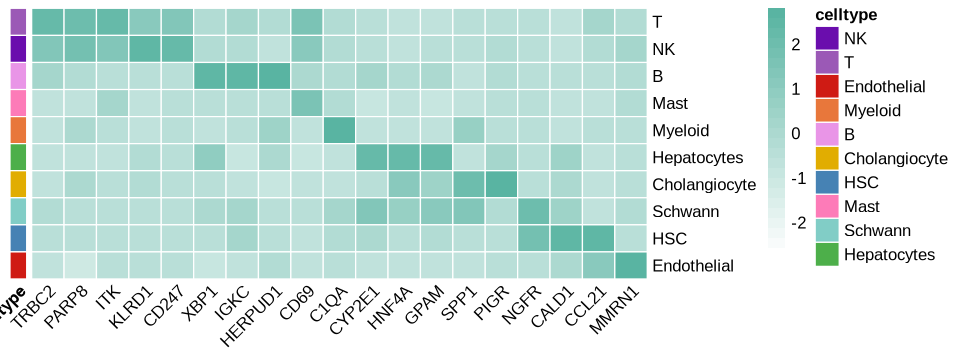

In [86]:
qgene <- setdiff(intersect(abc$gene, c("NGFR", rmarker$marker)), c("CD4", "CD93", "APOA2"))
rmat <- log2(rpkm[qgene, rev(corder)] + 1)

max_indices <- max.col(rmat)
permutation_vector <- order(max_indices)
smat <- rmat[rev(permutation_vector), corder]

canno <- colnames(smat) %>% as.data.frame() %>% 
tibble::column_to_rownames(".") %>% 
mutate(celltype = rownames(.)) %>% 
select(celltype)
ccolor <- list(celltype = c(celltype_colors))

options(repr.plot.width = 8, repr.plot.height = 3)
t0 <- smat %>% t %>%
pheatmap(scale = "column",cluster_rows = F, cluster_cols = F, angle_col = 45, 
         annotation_row = canno, annotation_colors = ccolor,
         border_color = "white", color = colorRampPalette(c("white", "#59b4a2"))(25))

In [83]:
### For marker genses, find the regulated elements and plot epigenetics mark
ataccor <- accor <- mecor <- matrix(data = 0, nrow = length(qgene), 
                                    ncol = length(corder), dimnames = list(qgene, corder))
for (f in qgene){
    ccre <- abc %>% filter(gene == f) %>% select(peak) %>% unlist %>% unique
    ataccor[f,] <- apply(atac[ccre,corder], MARGIN = 2, mean, na.rm = TRUE)
    accor[f,] <- apply(k27ac[ccre,corder], MARGIN = 2, mean, na.rm = TRUE)
    mecor[f,] <- apply(k27me3[ccre,corder], MARGIN = 2, mean, na.rm = TRUE)
}

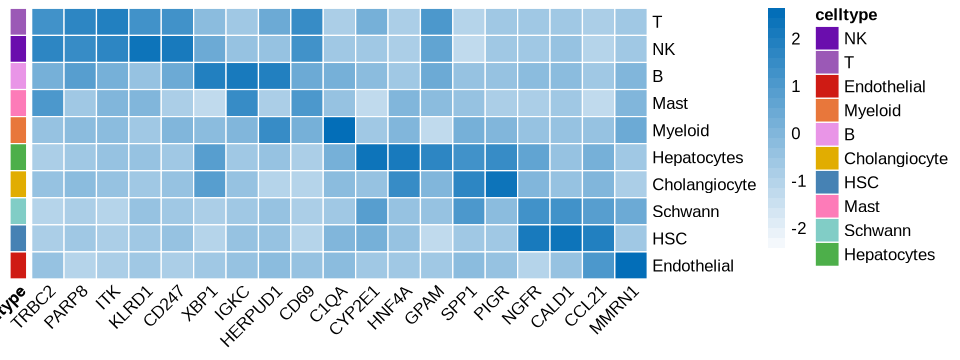

In [88]:
t1 <- log2(ataccor + 1)[rownames(smat), colnames(smat)] %>% t %>%
pheatmap(scale = "column",cluster_rows = F, cluster_cols = F, angle_col = 45, 
         annotation_row = canno, annotation_colors = ccolor,
         border_color = "white", color = colorRampPalette(c("white", "#036EB8"))(25))

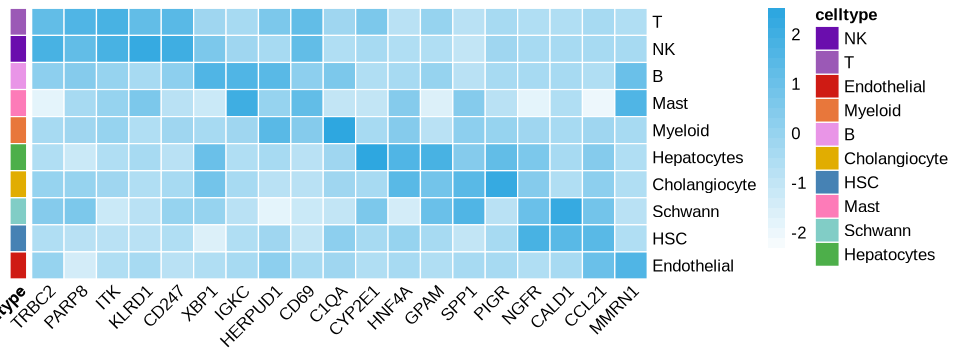

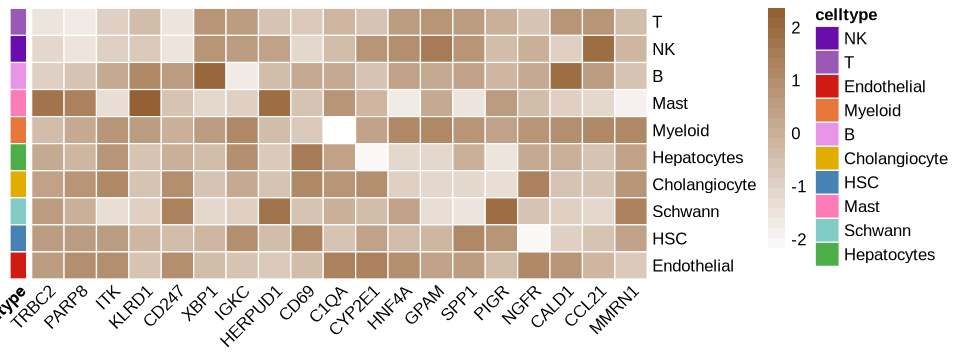

In [89]:
qmat <- log2(accor + 1)[rownames(smat), colnames(smat)]
t2 <- qmat %>% t %>%
pheatmap(scale = "column",cluster_rows = F, cluster_cols = F, angle_col = 45, 
         annotation_row = canno, annotation_colors = ccolor,
         border_color = "white", color = colorRampPalette(c("white", "#2EA7E0"))(25))

qmat <- log2(mecor + 1)[rownames(smat), colnames(smat)]
t3 <- qmat %>% t %>%
pheatmap(scale = "column",cluster_rows = F, cluster_cols = F, angle_col = 45, 
         annotation_row = canno, annotation_colors = ccolor,
         border_color = "white", color = colorRampPalette(c("white", "#956134"))(25))

## Side by side plot all ATAC elements

In [6]:
### read order: from NMF
tmp <- read.table("../reference/241022_Peaks/NMF/res/FNIH_Liver_pool.ATAC_celltype.LiverUnionPeaks.r9n10.statW", skip = 1)
tmp$V1 <- sub("-", ":", tmp$V1)
eorder <- tmp %>% mutate(V3 = factor(V3, levels = c(0, 6, 2, 4,7,3,5,8,1))) %>%# filter(V1 %in% share) %>% 
arrange(V3) %>% select(V1) %>% unlist

In [10]:
### Output for annotation
system("mkdir -p ../reference/241022_Peaks/NMF/module/anno")
tmp[,c("chrom", "start", "end")] <- stringr::str_split_fixed(tmp$V1, pattern = "[:-]", n = 3)
for (f in unique(tmp$V3)){
    ttable <- tmp[tmp$V3 == f, c("chrom", "start", "end")]
    write.table(ttable, paste0("../reference/241022_Peaks/NMF/module/LiverUnionPeaks.r9n10.module", f, ".bed"),
                sep = "\t", quote = F, row.names = F, col.names = F)
}

In [31]:
gapr <- tmp %>% mutate(V3 = factor(V3, levels = c(0, 6, 2, 4,7,3,5,8,1))) %>%# filter(V1 %in% share) %>% 
arrange(V3) %>% select(V3) %>% table %>% cumsum %>% unlist

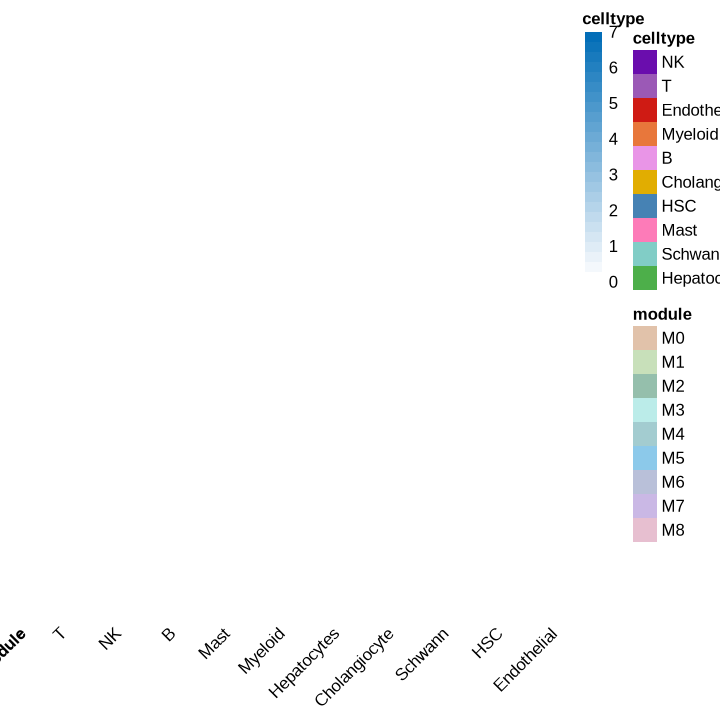

In [37]:
options(repr.plot.width = 6, repr.plot.height = 6)

rmat <- log2(atac[sub(":", "-", eorder), corder] + 1)
smat <- rmat #[permutation_vector, ]
smat[smat > 7] <- 7

ranno <- tmp %>% tibble::column_to_rownames("V1") %>% mutate(module = paste0("M", V3)) %>% select(module)
rownames(ranno) <- sub(":", "-", rownames(ranno))
colsn <- c("#e1c2aa","#c8e0ba","#95bfac","#bbece9","#a3ccd0","#8cc9ea","#b9c0d9","#cab8e5","#e7bfd0")
names(colsn) <- sort(unique(ranno$module))

canno <- tmp %>% tibble::column_to_rownames("V1") %>% mutate(celltype = rownames(.)) %>% select(celltype)
ccolor <- list(celltype = c(celltype_colors),
               module = colsn)

t1 <- smat %>%
pheatmap(scale = "none",cluster_rows = F, cluster_cols = F, angle_col = 45, gaps_row = gapr,
         annotation_colors = ccolor, 
         show_rownames = F, annotation_row = ranno, annotation_col = canno,
         border_color = NA, color = colorRampPalette(c("white", "#036EB8"))(25))
ggsave(t1, filename = "plot/FIG_ATAC_celltype_NMF.png", dpi = 300, height = 8, width = 6)

In [121]:
### Add chromatin states
slist <- list()
for (f in list.files("chromhmm/annotate/")){
    fname <- gsub("^Liver_UnionPeak_([^_]+)_annotate.bed$", "\\1", f)
    fbed <- read.table(paste0("chromhmm/annotate/", f)) %>% mutate(range = paste0(V1, ":", V2, "-", V3)) %>%
    select(c(range, V4)) %>%
    mutate(V4 = as.integer(gsub("E", "", V4))) %>% 
    group_by(range) %>%
    slice_sample(n = 1) %>%
    ungroup() %>%
    tibble::column_to_rownames("range") %>% setNames(fname)
    slist[[fname]] <- fbed
}

slist <- do.call(cbind, slist)
write.table(slist, "chromhmm/annotate/Liver_UnionPeak_chromhmm_by_celltype.xls", sep = "\t", quote = F,
            row.names = T, col.names = T)

### annotate all cCREs with chromatin states

In [52]:
tmp <- read.table("../reference/241022_Peaks/consensus/LiverUnionPeaks.bed", header = F)
sum(tmp$V3-tmp$V2)/2913022398 ### hg38

[1] 0.05993977

In [768]:
slist <- read.table("chromhmm/annotate/Liver_UnionPeak_chromhmm_by_celltype.xls", row.names = 1, header = T)
tmp <- read.table("../reference/241022_Peaks/NMF/res/FNIH_Liver_pool.ATAC_celltype.LiverUnionPeaks.r9n10.statW", skip = 1)
tmp$V1 <- sub("-", ":", tmp$V1)

smodule <- list() 
for (f in unique(tmp$V3)){
    qpeak <- tmp %>% filter(V3 == f) %>% select(V1) %>% unlist %>% as.character
    smodule[[paste0(f)]] <- slist[qpeak,] %>% 
    reshape2::melt() %>% table %>%
    as.data.frame %>% mutate(module = f)
}

smodule <- do.call(rbind, smodule)

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables

No id variables; using all as measure variables



In [765]:
options(repr.plot.width = 6, repr.plot.height = 12)
t1 <- smodule %>%
mutate(variable = factor(variable, levels = corder)) %>% #arrange(variable) %>%
mutate(module = factor(module, levels = c(0, 6, 2, 4,7,3,5,8,1))) %>%
ggplot(aes(x = variable, y = Freq, fill = as.character(value))) + 
geom_col(position = "fill", color = "white") + 
theme_Publication() + xlab("") + theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
scale_fill_manual(values = c('#66cdaa', "#008000", "#ffc800", "#cd5c5c", "#c0c0c0")) + 
facet_grid(module ~ .)

ggsave(t1, filename = "plot/FIG_celltype_module_statse.pdf", dpi = 150, height = 12, width = 6)

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


## Compare SCREEN to cCREs we have

In [771]:
screend <- read.table("/projects//ps-renlab2/y2xie/projects/genome_ref/SCREEN/GRCh38-cCREs.bed")
scsrange <- GRanges(screend$V1, ranges = IRanges(as.numeric(screend$V2), as.numeric(screend$V3)))

hed <- read.csv("/projects//ps-renlab2/y2xie/projects/public_data/Zhang2021_HumanAtlas/cCRE_hg38.tsv.gz", sep = '\t') %>% 
mutate(range = paste0(X.Chromosome, "-", hg38_Start, "-", hg38_End))
tmp1 <- hed[hed[,5] == "yes" & hed[,6] == "no",] # fetal only
tmp2 <- hed[hed[,5] == "no" & hed[,6] == "yes",] # adult only
tmp3 <- hed[hed[,5] == "yes" & hed[,6] == "yes",] # shared

hedrange <- GRanges(hed[,1], ranges = IRanges(as.numeric(hed[,2]), as.numeric(hed[,3])))
hedrange1 <- GRanges(tmp1[,1], ranges = IRanges(as.numeric(tmp1[,2]), as.numeric(tmp1[,3])))
hedrange2 <- GRanges(tmp2[,1], ranges = IRanges(as.numeric(tmp2[,2]), as.numeric(tmp2[,3])))
hedrange3 <- GRanges(tmp3[,1], ranges = IRanges(as.numeric(tmp3[,2]), as.numeric(tmp3[,3])))

tmp[,c("chrom", "start", "end")] <- stringr::str_split_fixed(tmp$V1, pattern = "[:-]", n = 3)
trange <- GRanges(tmp$chrom, ranges = IRanges(as.numeric(tmp$start), as.numeric(tmp$end)))

In [776]:
ctp <- readMM("/projects//ps-renlab2/y2xie/projects/public_data/Zhang2021_HumanAtlas/cCRE_by_cell_type/matrix.tsv.gz")
celltype <- read.table("/projects//ps-renlab2/y2xie/projects/public_data/Zhang2021_HumanAtlas/cCRE_by_cell_type/celltypes.txt.gz", sep = '\t')
peak <- read.table("/projects//ps-renlab2/y2xie/projects/public_data/Zhang2021_HumanAtlas/cCRE_by_cell_type/cCREs.bed.gz", sep = '\t') %>%
mutate(range = paste0(V1, "-", V2, "-", V3))
rownames(ctp) <- peak$range
colnames(ctp) <- celltype$V1

In [777]:
hemeta <- read.csv("/projects//ps-renlab2/y2xie/projects/public_data/Zhang2021_HumanAtlas/Cell_metadata.tsv.gz", sep = "\t")
ccount <- hemeta[grep('liver', hemeta$tissue), ]$cell.type %>% table %>% as.data.frame
qcelltype <- ccount %>% filter(Freq >= 10) %>% arrange(Freq) %>% select('.') %>% unlist %>% as.character

In [ ]:
qcelltype %>% length
intersect(qcelltype, colnames(ctp)) %>% length
unmatch <- c("Fetal Endothelial General 2", "Fetal Schwann General", "Fetal Ureteric Bud", "Pericyte General 1", "Endothelial General 1",
  "Endothelial General 1", 'Fibro General', "Fetal Mesothelial", "Macrophage Gen or Alv", "Fetal Adrenal Cortical", "Ductal", 'Fetal Endothelial Placental',
  'Fetal Lymphatic', 'Fetal Metanephric', 'Fetal Fibro General 4', 'Fetal Fibro General 3', 'Fetal Macrophage General 4', 
  'Macrophage General', 'Endothelial Exocrine', 'Fetal Fibro Placental 1', 'Fetal Alveolar Epithelial 1', 'Fetal Macrophage General 2',
  'Fetal Fibro General 1', 'Fetal Macrophage General 1', "Fetal Endothelial General 1", 'Fetal Fibro GI', 'Fibro Liver Adrenal', 'Fetal Endothelial General 3',
  'Fetal Macrophage General 3', 'Fetal Fibro General 2', 'Fetal Cholangiocyte', 'Fetal Hepatoblast', 'Fetal Macrophage Hepatic 1', 'Fetal Macrophage Hepatic 2', 'Fetal Macrophage Hepatic 3',
  'Fetal Hematopoeitic Stem', 'Fetal Stellate', 'Fetal Endothelial Hepatic 1', 'Fetal Endothelial Hepatic 2')

In [779]:
livpeak <- ctp[,liv] %>% rowSums %>% as.data.frame %>% setNames("count") %>% filter(count > 0) %>% rownames
tmp1 <- hed[hed[,5] == "yes" & hed[,6] == "no" & hed$range %in% livpeak,] # fetal only
tmp2 <- hed[hed[,5] == "no" & hed[,6] == "yes" & hed$range %in% livpeak,] # adult only
tmp3 <- hed[hed[,5] == "yes" & hed[,6] == "yes" & hed$range %in% livpeak,] # shared

hedrange <- GRanges(hed[hed$range %in% livpeak,1], 
                    ranges = IRanges(as.numeric(hed[hed$range %in% livpeak,2]), as.numeric(hed[hed$range %in% livpeak,3])))
hedrange1 <- GRanges(tmp1[,1], ranges = IRanges(as.numeric(tmp1[,2]), as.numeric(tmp1[,3])))
hedrange2 <- GRanges(tmp2[,1], ranges = IRanges(as.numeric(tmp2[,2]), as.numeric(tmp2[,3])))
hedrange3 <- GRanges(tmp3[,1], ranges = IRanges(as.numeric(tmp3[,2]), as.numeric(tmp3[,3])))

In [780]:
w1 <- queryHits(findOverlaps(trange, scsrange))
w2 <- queryHits(findOverlaps(trange, hedrange))
w3 <- queryHits(findOverlaps(trange, hedrange1)) ### fetal
w4 <- queryHits(findOverlaps(trange, hedrange2)) ### adult
w5 <- queryHits(findOverlaps(trange, hedrange3)) ### shared

tmp$V1 %>% unique %>% length
w1 %>% unique %>% length
w2 %>% unique %>% length
w3 %>% unique %>% length
w4 %>% unique %>% length
w5 %>% unique %>% length

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chr17_KI270909v1_alt, chr19_KI270938v1_alt, chr1_KI270706v1_random, chr22_KI270879v1_alt, chr4_GL000008v2_random, chr7_KI270803v1_alt, chr8_KI270821v1_alt, chrUn_KI270742v1
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM
  - in 'y': chr17_KI270909v1_alt, chr19_KI270938v1_alt, chr1_KI270706v1_random, chr22_KI270879v1_alt, chr4_GL000008v2_random, chr7_KI270803v1_alt, chr8_KI270821v1_alt, chrUn_KI270742v1
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”


[1] 611576

[1] 345510

[1] 351808

[1] 36374

[1] 31814

[1] 286876

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


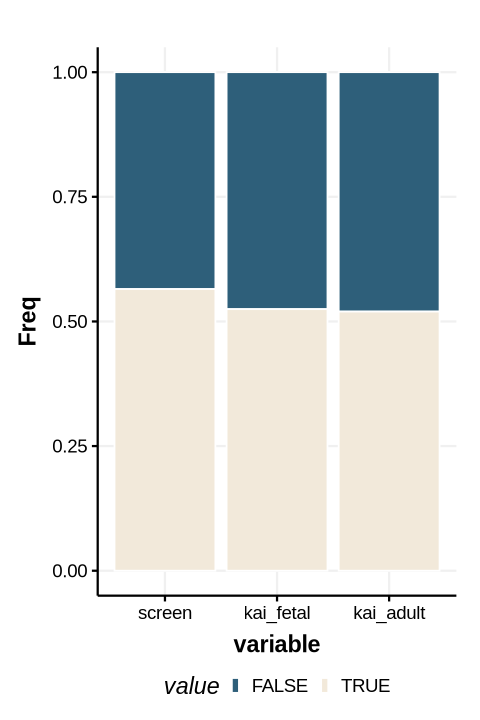

In [781]:
options(repr.plot.width = 4, repr.plot.height = 6)
t1 <- tmp$V1 %>%
as.data.frame %>% setNames("peaks") %>%
mutate(screen = ifelse(peaks %in% tmp$V1[w1], "TRUE", "FALSE")) %>%
# mutate(kai = ifelse(peaks %in% tmp$V1[w2], "TRUE", "FALSE")) %>%
mutate(kai_fetal = ifelse(peaks %in% tmp$V1[unique(c(w3, w5))], "TRUE", "FALSE")) %>%
mutate(kai_adult = ifelse(peaks %in% tmp$V1[unique(c(w4, w5))], "TRUE", "FALSE")) %>%
reshape2::melt(id.vars = "peaks") %>%
select(c(variable,value)) %>% table %>%
as.data.frame %>%
ggplot(aes(x = variable, y = Freq, fill = value)) + 
geom_col(position = "fill", color = "white") + 
theme_Publication() + 
scale_fill_manual(values = c("#2E5F7A", "#F2E9DA"))

t1
# ggsave(t1, filename = "plot/FIG_cCRE_compare_SCREEN_HA.pdf", dpi = 300, height = 6, width = 4)

In [787]:
### New elements: not in all others
nele <- tmp$V1 %>%
as.data.frame %>% setNames("peaks") %>%
mutate(screen = ifelse(peaks %in% tmp$V1[w1], "TRUE", "FALSE")) %>%
mutate(kai_fetal = ifelse(peaks %in% tmp$V1[unique(c(w3, w5))], "TRUE", "FALSE")) %>%
mutate(kai_adult = ifelse(peaks %in% tmp$V1[unique(c(w4, w5))], "TRUE", "FALSE")) %>%
filter(screen == 'FALSE', kai_fetal == 'FALSE', kai_adult == 'FALSE') %>%
select(peaks) %>% unlist

nele <- stringr::str_split_fixed(nele, pattern = "[:-]", n = 3) %>% as.data.frame
write.table(nele, "../reference/241022_Peaks/newcompare/New_element_SCREEN_HEA.bed", sep = '\t', 
            quote = F, row.names = F, col.names = F)

### Load annotation of peaks

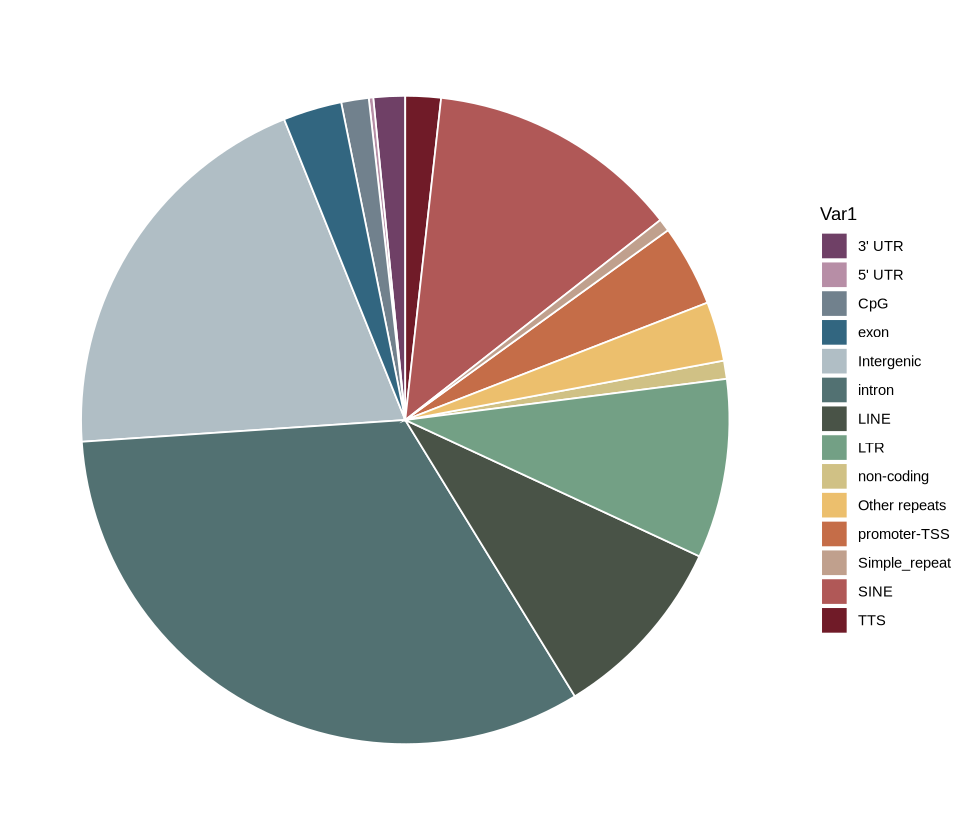

In [196]:
panno <- read.csv(paste0("../reference/241022_Peaks/consensus/annotation/LiverUnionPeaks.anno"), sep = "\t") %>% 
mutate(ccre = paste0(Chr, ":", Start, "-", End))

t1 <- sum_detailed_anno(panno[panno$Chr != "chrM", ]) %>% 
mutate(percentage = (Freq / sum(Freq)) * 100,
       label = paste0(round(percentage, 2), "%"),
       ypos = (cumsum(Freq) - Freq) / 2) %>%
ggplot(aes(x = "", y = Freq, fill = Var1)) +
geom_bar(width = 1, stat = "identity", color = "white") +
coord_polar(theta = "y") + 
# geom_text(aes(y = ypos, label = label), position = position_stack(vjust = -0.5)) +
theme_void() + #theme(legend.position = "none") +  # Remove legend if not needed
scale_fill_manual(values = colfunc(14))

t1

# ggsave(t1, filename = "plot/FIG_cCRE_annotation.pdf", dpi = 300, height = 6, width = 6)

In [71]:
newanno <- read.csv("../reference/241022_Peaks/newcompare/New_element_SCREEN_HEA.anno", sep = "\t") %>% 
mutate(ccre = paste0(Chr, ":", Start, "-", End))

tdata1 <- sum_detailed_anno(newanno[newanno$Chr != "chrM", ]) %>% 
mutate(percentage = (Freq / sum(Freq)) * 100,
       label = paste0(round(percentage, 2), "%"),
       ypos = (cumsum(Freq) - Freq) / 2) %>% mutate(class = "old") ### old
tdata2 <- sum_detailed_anno(panno[panno$ccre %in% setdiff(panno$ccre, newanno$ccre) & panno$Chr != "chrM", ]) %>% 
mutate(percentage = (Freq / sum(Freq)) * 100,
       label = paste0(round(percentage, 2), "%"),
       ypos = (cumsum(Freq) - Freq) / 2) %>% mutate(class = "new") ### new

### Plot new and old elements seprately
fig1 <- rbind(tdata1, tdata2) %>%
mutate(group = factor(class, levels = c("old", "new"))) %>%
mutate(Var1 = factor(Var1, levels = sort(unique(Var1)))) %>%
arrange(group) %>% 
ggplot(aes(x = group, y = Freq, fill = Var1)) +
geom_col(position = "fill", color = "white") +
coord_radial(theta = "y", start = 0, end = 2.15 * pi, inner.radius = 0) + 
scale_x_discrete(limits = c(" ", "old", "new")) + 
theme_void() + scale_fill_manual(values = colfunc(14))
fig1
ggsave(fig1, filename = "plot/FIG_cCRE_annotation_new_old.pdf", dpi = 300, height = 6, width = 6)

## Calcualte and plot celltype specific elements

In [262]:
### prepare and read norm / scaled data for calculating
prop.norm.df <- read.csv("../reference/241022_Peaks/FNIH_Liver_cellsubtype_prop_norm_df.csv", header = T, row.names = 1)
prop.scale.df <- read.csv("../reference/241022_Peaks/FNIH_Liver_cellsubtype_prop_scale_df.csv", header = T, row.names = 1)
lr.df <- read.csv("../reference/241022_Peaks/snapatac2_cellsubtype_LR_test.csv")
attr.lst <- unique(meta$cellsubtype)

In [265]:
suppressPackageStartupMessages(library("philentropy"))
suppressPackageStartupMessages(library("fdrtool"))
eFDR <- 0.01
calJSD <- function(p, q){
    P <- p
    Q <- q
    x <- rbind(P,Q)
    suppressMessages(JSD(x))
}

jss.df <- data.frame(peaks=as.character(),
                     JSD=as.numeric(),
                     JSS=as.numeric(),
                     z=as.numeric(),
                     normCPM = as.numeric(),
                     JSscore=as.numeric(),
                     attr=as.character(),
                     group=as.character(),
                     zPval=as.numeric(),
                     zQval=as.numeric(),
                     zLocFDR=as.numeric(),
                     zCUT=as.numeric(),
                     JSSeFDRcut=as.numeric(),
                     passJSS=as.character())

for(i in 1:length(attr.lst)){
    attr.sel <- attr.lst[i]
    celltype <- meta %>% filter(cellsubtype == attr.sel) %>% select(celltype) %>% unlist %>% unique
    peaks <- read.table(paste0("../reference/241022_Peaks/consensus/", celltype, "_peaks.union.bed")) %>%
    mutate(range = paste0(V1, "-", V2, "-", V3))
    diffgene <- lr.df %>% filter(celltype == attr.sel & adjusted.p.value < 0.05) %>% select(feature.name) %>% unlist
    Q <- rep(0, length(attr.lst))
    Q[i] <- 1
    jsd <- apply(prop.scale.df[intersect(rownames(prop.scale.df), peaks$range), ], 1, calJSD, q=Q)
    jss <- 1 - sqrt(jsd)

    out <- data.frame(peaks = intersect(rownames(prop.scale.df), peaks$range)) 
    out$JSD <- jsd
    out$JSS <- jss
    out$z <- ( jss - mean(jss) ) / sd(jss)
    out$normCPM <- prop.norm.df[intersect(rownames(prop.scale.df), peaks$range),i]
    out$JSscore <- jss^2 * prop.norm.df[intersect(rownames(prop.scale.df), peaks$range),i]
    out$attr <- attr.sel
    out$group <- "bgd"
    idx <- which(gsub(":", "-", out$peaks) %in% gsub(":", "-", diffgene))
    out[idx, "group"] <- "diff"

    # fit
    fdrOUT <- fdrtool(out$z, plot=FALSE)
    zCUT <- fdrOUT$param[,"cutoff"]
    out$zPval <- fdrOUT$pval
    out$zQval <- fdrOUT$qval
    out$zLocFDR <- fdrOUT$lfdr
    out$zCUT<- zCUT
    JSSeFDRcut <- quantile(out[which(out$group=="bgd"), ][["JSS"]], 1-eFDR)
    out$JSSeFDRcut <- JSSeFDRcut
    out$passJSS <- "no"
    out[which(out$JSS > JSSeFDRcut), "passJSS"] <- "yes"
    jss.df <- rbind(jss.df, out)
}

Step 1... determine cutoff point
Step 2... estimate parameters of null distribution and eta0
Step 3... compute p-values and estimate empirical PDF/CDF
Step 4... compute q-values and local fdr

Step 1... determine cutoff point
Step 2... estimate parameters of null distribution and eta0
Step 3... compute p-values and estimate empirical PDF/CDF
Step 4... compute q-values and local fdr

Step 1... determine cutoff point
Step 2... estimate parameters of null distribution and eta0
Step 3... compute p-values and estimate empirical PDF/CDF
Step 4... compute q-values and local fdr

Step 1... determine cutoff point
Step 2... estimate parameters of null distribution and eta0
Step 3... compute p-values and estimate empirical PDF/CDF
Step 4... compute q-values and local fdr

Step 1... determine cutoff point
Step 2... estimate parameters of null distribution and eta0
Step 3... compute p-values and estimate empirical PDF/CDF
Step 4... compute q-values and local fdr

Step 1... determine cutoff point
St

In [266]:
data.table::fwrite(jss.df, paste0("../reference/241022_Peaks/FNIH_Liver.cellsubtype.FDR001.JSStest.out.tsv"))

In [267]:
pdfname <- paste("../reference/241022_Peaks/FNIH_Liver.cellsubtype.FDR001.JSStest.fit.pdf", sep=".")
pdf(pdfname)

for(i in 1:length(attr.lst)){
    attr.sel <- attr.lst[i]
    dat <- jss.df[which(jss.df$attr == attr.sel), ]
    zCUT <- unique(dat$zCUT)
    JSSeFDRcut <- unique(dat$JSSeFDRcut)

    p1 <- ggplot(dat, aes(x=JSS)) +
      geom_density(aes(fill=group), alpha=0.5) +
      theme_bw() + ggtitle(paste(attr.sel, " (JSS)", sep="")) +
      geom_vline(xintercept = JSSeFDRcut, color="black") +
      theme(axis.text.x=element_text(colour = "black", size = 8),
            axis.text.y=element_text(colour = "black", size = 8),
            axis.title.x=element_text(colour = "black", size = 8),
            axis.title.y=element_text(colour = "black", size = 8))

    p2 <- ggplot(dat, aes(x=z)) +
      geom_density(fill="grey", alpha=0.5) +
      theme_bw() + ggtitle(paste(attr.sel, " (z-score of JSS)", sep="")) +
      geom_vline(xintercept = zCUT) +
      theme(axis.text.x=element_text(colour = "black", size = 8),
            axis.text.y=element_text(colour = "black", size = 8),
            axis.title.x=element_text(colour = "black", size = 8),
            axis.title.y=element_text(colour = "black", size = 8))
    print(p1)
    print(p2)
}
dev.off()

pdf 
  2

In [15]:
label <- "celltype"
if (label == "cellsubtype"){
    jssdf <- data.table::fread(paste0("../reference/241022_Peaks/consensus/LR/FNIH_Liver.", label, ".FDR001.JSStest.out.tsv"))
}else{
    jssdf <- data.table::fread(paste0("../reference/241022_Peaks/consensus/LR/FNIH_Liver.", label, ".JSStest.out.tsv"))
}

jssdf %>% filter(group == "diff") %>% select(attr) %>% table
jssdf %>% filter(group == "diff" & passJSS == "yes") %>% select(attr) %>% table

attr
            B Cholangiocyte   Endothelial   Hepatocytes           HSC 
        13598         12557         10355         12995          8948 
         Mast       Myeloid            NK       Schwann             T 
         3022         12858         13382          4202         12303 

attr
            B Cholangiocyte   Endothelial   Hepatocytes           HSC 
        12301         11985          9956         12953          8823 
         Mast       Myeloid            NK       Schwann             T 
         1223         12498         13235          3170         12245 

In [16]:
### Find peaks specific to some or one cell types
cts <- jssdf %>% filter(passJSS == "yes" & group == "diff") %>% select(c(peaks, attr)) %>% table %>%
as.data.frame %>% filter(Freq > 0) %>%
group_by(peaks) %>% summarise(celltype = paste0(attr, collapse = "|")) %>%
ungroup

write.table(cts, paste0("../reference/241022_Peaks/LR/FNIH_Liver.", label, "_specific_peaks.txt"), 
            sep = "\t", quote = F, row.names = F, col.names = F)

### Plot SCENIC+ linked elements

In [14]:
grn <- read.table("GRN//Scenic_outs//alldata_50k_v2_otsu//eRegulon_direct.tsv", header = T)
head(grn)
dim(grn)

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>
1,chr18:36188338-36188542,SLC39A6,0.11051557,0.1229949,0.013592846,0.013592846,AHR,False,AHR_direct_+/+,AHR_direct_+/+_(19g),AHR_direct_+/+_(17r),0.1647406,1,0.07885978,42422
2,chr17:81245100-81245400,NDUFAF8,0.02233528,0.1225278,0.002736693,0.002736693,AHR,False,AHR_direct_+/+,AHR_direct_+/+_(19g),AHR_direct_+/+_(17r),0.2649546,1,0.09525132,124174
3,chr6:36096009-36096309,BRPF3,0.06250880,0.1144717,0.007155488,0.007155488,AHR,False,AHR_direct_+/+,AHR_direct_+/+_(19g),AHR_direct_+/+_(17r),0.2342992,1,0.11596887,37597
4,chr4:88159008-88159308,ABCG2,0.06288524,0.1882791,0.011839975,0.011839975,AHR,False,AHR_direct_+/+,AHR_direct_+/+_(19g),AHR_direct_+/+_(17r),0.1810327,1,0.11602202,147141
5,chr18:23662714-23663014,ANKRD29,0.02826424,0.1696246,0.004794311,0.004794311,AHR,False,AHR_direct_+/+,AHR_direct_+/+_(19g),AHR_direct_+/+_(17r),0.1897218,1,0.05652630,13967
6,chr10:133525489-133525789,CYP2E1,0.03427282,0.7076489,0.024253125,0.024253125,AHR,False,AHR_direct_+/+,AHR_direct_+/+_(19g),AHR_direct_+/+_(17r),0.3055872,1,0.33291654,102007


[1] 186501     15

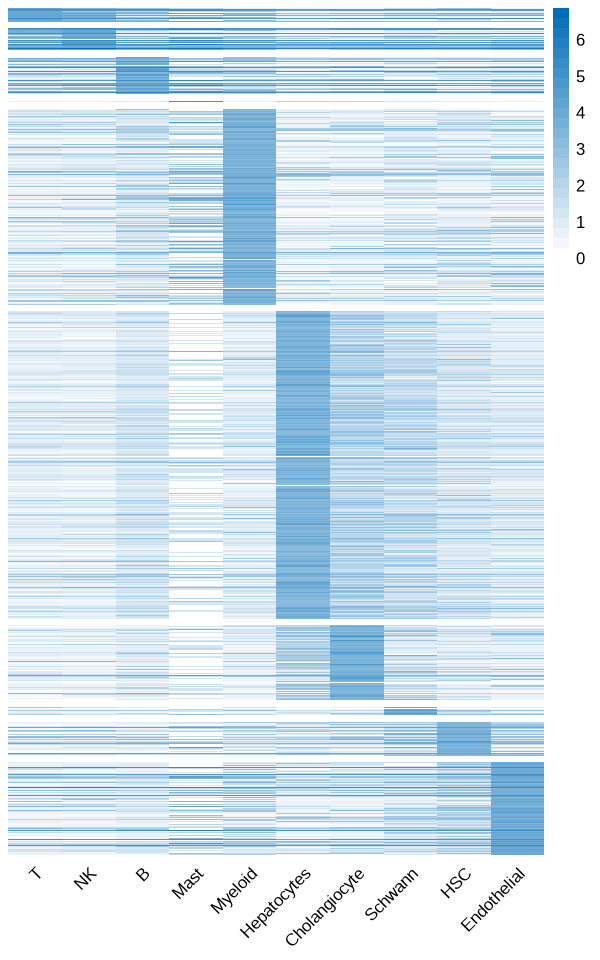

In [21]:
atac <- read.table("../reference/ATAC_by_celltype.241130.cpm.txt")
ctp <- cts[grep("\\|", cts$celltype, invert = T), ] %>% 
mutate(celltype = factor(celltype, levels = corder)) %>%
arrange(celltype) %>% select(peaks) %>% unlist %>% as.character

tmp <- cts[cts$peaks %in% ctp,] %>% mutate(peaks = sub("-", ":", peaks))
tmp <- merge(distinct(grn[,1:4]), tmp, by.x = "Region", by.y = "peaks") %>%
mutate(celltype = factor(celltype, levels = corder)) %>%
arrange(celltype)

rmat <- atac[sub(":", "-", tmp$Region), corder]
max_indices <- max.col(rmat)
permutation_vector <- order(max_indices)
smat <- rmat#[permutation_vector, ]

options(repr.plot.width = 5, repr.plot.height = 8)
t1 <- log2(smat + 1) %>%
pheatmap(scale = "none",cluster_rows = F, cluster_cols = F, angle_col = 45, 
         gaps_row = unlist(cumsum(table(tmp$celltype))),
         show_rownames = F, border_color = NA, color = colorRampPalette(c("white", "#036EB8"))(25))

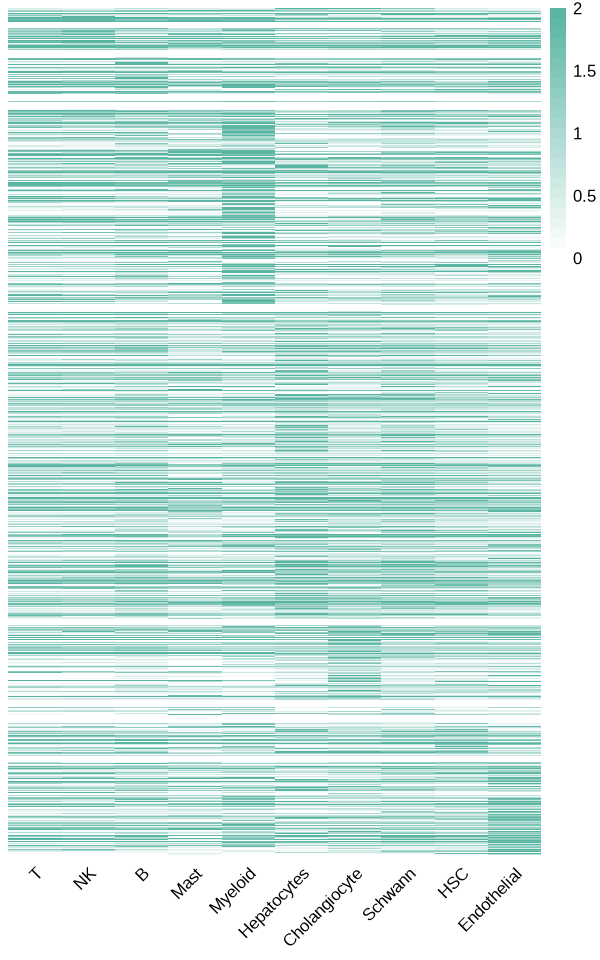

In [22]:
rpkm <- read.table("integration/FNIH_Liver_pool.int.rpkm.txt", row.names = 1, header = T, sep = "\t")
smat1 <- log2(rpkm[tmp$Gene, corder]+1)
smat1[smat1 > 2] <- 2
t2 <- smat1 %>%
pheatmap(scale = "none",cluster_rows = F, cluster_cols = F, angle_col = 45, 
         gaps_row = unlist(cumsum(table(tmp$celltype))),
         show_rownames = F, border_color = NA, color = colorRampPalette(c("white", "#59b4a2"))(25))

In [594]:
tmp[,c("chrom", "start", "end")] <- stringr::str_split_fixed(tmp$Region, pattern = "[:-]", n = 3)
write.table(tmp[,c("chrom", "start", "end", "Region", "Gene", "celltype")], 
            "GRN/celltype_specific_links.txt", sep = "\t", quote = F, row.names = F, col.names = T)

In [314]:
unique(tmp$Region) %>% length
unique(tmp$Gene) %>% length

[1] 12410

[1] 7422

In [609]:
### Try plotting TF in GRN?
tflist <- list()
for (i in 1:nrow(tmp)){
    tflist[[i]] <- grn %>% filter(Region == tmp[i,]$Region & Gene == tmp[i,]$Gene) %>%
    mutate(celltype = tmp[i,]$celltype)
}
tflist <- do.call(rbind, tflist)
tflist %>% head

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank,celltype
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<fct>
1,chr1:112618977-112619277,ST7L,0.0348312967,-0.07990479,-0.0027831873,0.0027831873,UBE2K,False,UBE2K_direct_+/-,UBE2K_direct_+/-_(1432g),UBE2K_direct_+/-_(1776r),0.9546485,1,0.23619056,156605,T
2,chr1:112618977-112619277,ST7L,0.0348312967,-0.07990479,-0.0027831873,0.0027831873,ZNF148,False,ZNF148_direct_+/-,ZNF148_direct_+/-_(1130g),ZNF148_direct_+/-_(2679r),1.3869980,1,0.25568640,138969,T
3,chr1:113783532-113783832,PHTF1,0.0298961541,-0.06096126,-0.0018225073,0.0018225073,PURA,False,PURA_direct_+/-,PURA_direct_+/-_(61g),PURA_direct_+/-_(83r),0.2173789,1,0.07125702,150840,T
4,chr1:12177938-12178238,TNFRSF1B,0.0307289786,0.13997340,0.0043012397,0.0043012397,CREM,False,CREM_direct_+/+,CREM_direct_+/+_(191g),CREM_direct_+/+_(340r),2.5473180,1,0.26526263,95704,T
5,chr1:202162067-202162367,ELF3,0.0006960452,-0.21031491,-0.0001463887,0.0001463887,ETS2,False,ETS2_direct_+/-,ETS2_direct_+/-_(514g),ETS2_direct_+/-_(2033r),0.7459000,1,0.22475968,177259,T
6,chr1:202164591-202164891,ELF3,0.0005126506,-0.21460243,-0.0001100161,0.0001100161,ETS2,False,ETS2_direct_+/-,ETS2_direct_+/-_(514g),ETS2_direct_+/-_(2033r),0.7459000,1,0.22475968,180037,T


In [614]:
write.table(tflist[,c("Region", "Gene", "TF", "celltype")], 
            "GRN/celltype_specific_links_TF.txt", sep = "\t", quote = F, row.names = F, col.names = T)

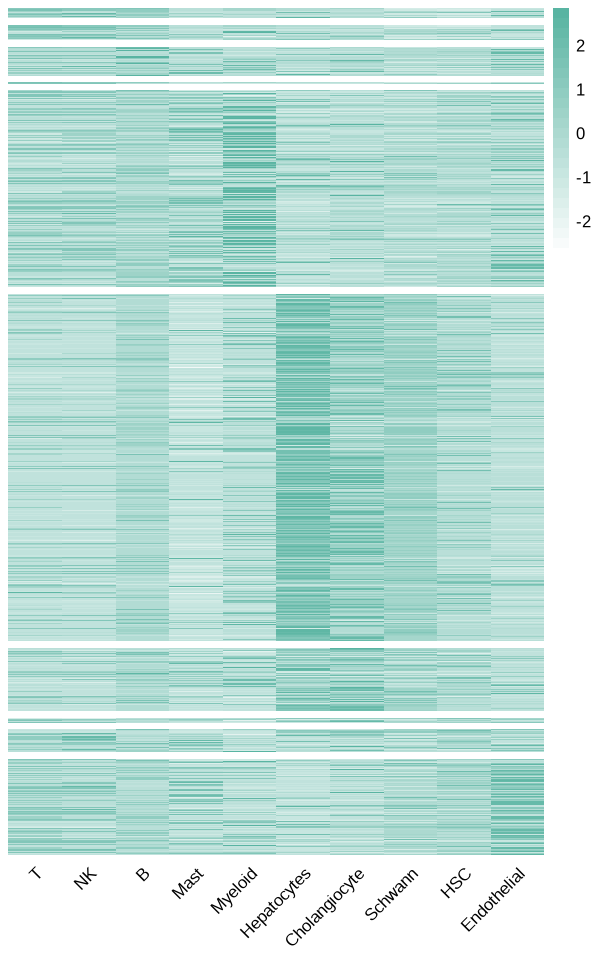

In [613]:
smat2 <- log2(rpkm[tflist$TF, corder]+1)
t3 <- smat2 %>%
pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, 
         gaps_row = unlist(cumsum(table(tflist$celltype))),
         show_rownames = F, border_color = NA, color = colorRampPalette(c("white", "#59b4a2"))(25))

ggsave(t3, filename = "plot/FIG_cts_GRN_TF_RPKM_zscore.pdf", dpi = 300, height = 5, width = 5)

In [ ]:
### output pairs for APA
hg38 <- read.table("/projects//ps-renlab/y2xie/projects/genome_ref/refdata-cellranger-arc-GRCh38-2020-A-2.0.0/regions/tss_1500bp.bed")
tmp <- read.table("GRN/celltype_specific_links.txt", header = T)
qpair <- merge(tmp, hg38, by.x = "Gene", by.y = "V7") %>%
select(c(chrom, start, end, V1, V2, V3, celltype)) %>%
distinct

for (f in unique(qpair$celltype)){
    tpair <- qpair %>% filter(celltype == f)
    write.table(tpair[,1:6], paste0("GRN//APA/", f, ".bedpe"), sep = "\t", quote = F, row.names = F, col.names = F)
}

In [337]:
qpair <- merge(tmp, hg38, by.x = "Gene", by.y = "V7") %>%
select(c(chrom, start, end, V1, V2, V3, celltype)) %>%
distinct

qpair <- qpair %>% 
setNames(c('chr1', 'x1', 'x2', 'chrom2', 'start2', 'end2', 'name')) %>%
mutate(score = 1000, strand1 = '*', strand2 = '*')
ccolor <- lapply(celltype_colors, function(x) paste(as.vector(col2rgb(x)),collapse = ",")) %>%
as.data.frame %>% t %>% as.data.frame %>% setNames("color")

qpair <- merge(qpair, ccolor, by.x = 'name', by.y = 0)
write.table(qpair[,c('chr1', 'x1', 'x2', 'chrom2', 'start2', 'end2', 'name', 'color')], 
            "GRN/celltype_specific_links.bedpe", sep = "\t", quote = F, row.names = F, col.names = T)

Using id as id variables

Using id as id variables



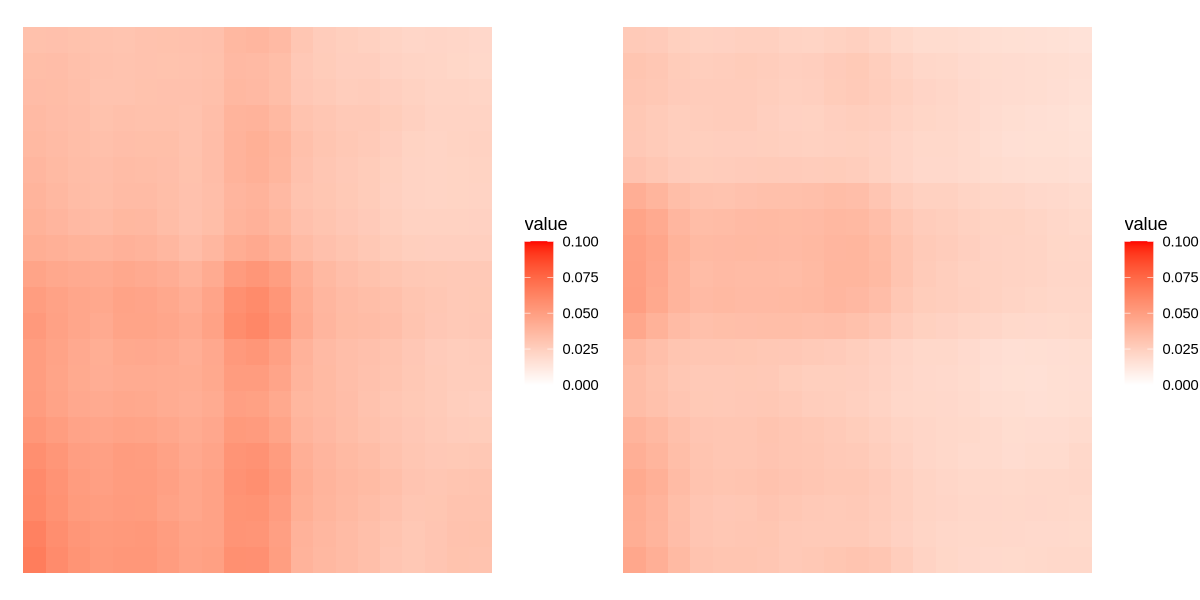

In [381]:
### plot Hepa
plist <- list()
for (f in c("Hepatocytes", "Myeloid")){ ### all but hepa and remove overlap by bedtools pairtopair
    tmp <- read.csv(paste0("GRN//APA/Hepatocytes_10kb/", f, "/10000/gw/APA.txt"), header = F)
    tmp$V1 <- gsub("\\[", "", tmp$V1) %>% as.numeric
    tmp$V21 <- gsub("\\]", "", tmp$V21) %>% as.numeric
    plist[[f]] <- tmp %>% mutate(id = colnames(.)) %>%
    reshape2::melt() %>% 
    mutate(id = as.integer(gsub("V", "", id))) %>% arrange(id) %>% 
    mutate(variable = as.integer(gsub("V", "", variable))) %>% arrange(variable) %>% 
    ggplot(aes(x = -id, y = variable, fill = value)) + 
    geom_tile() + theme_void() + 
    scale_fill_gradientn(colours = c("white", "red"), limits = c(0, 0.1))
}

options(repr.plot.width = 10, repr.plot.height = 5)
fig1 <- cowplot::plot_grid(plotlist = plist, ncol = 2)
fig1
ggsave(fig1, filename = "plot/FIG_GRN_ctsATACpeak_pairs_impute10k_APA_Hepa_vs_rest.pdf", dpi = 300, height = 4, width = 8)

## Plot motif and GO terms

In [162]:
motif <- list()
for (f in list.files("../reference/241224_WE_ct_specific_links/homer/")){
    fname <- gsub("241224_specific_links.", "", f)
    motif[[fname]] <- read.csv(paste0("../reference/241224_WE_ct_specific_links/homer/", f, "/knownResults.txt"), sep = "\t") %>%
    setNames(c("motif", "consensus", "p_value", "log_p_value", "fdr", "tgt_num", "tgt_pct", "bgd_num", "bgd_pct")) %>%
    mutate(celltype = fname)
}

ffile <- do.call(rbind, motif)

vmotif <- do.call(rbind, motif) %>% group_by(motif) %>% 
filter(min(fdr) < 0.05) %>% ungroup() %>%
select(motif) %>% unlist %>% unique

motif <- do.call(rbind, motif) %>%
filter(motif %in% vmotif) %>%
reshape2::dcast(celltype ~ motif, value.var = "p_value") %>%
tibble::column_to_rownames("celltype") %>% t
motif[is.na(motif)] <- 1
motif <- -log2(motif)
motif[motif > 10] <- 10

rmat <- motif[, corder]
max_indices <- max.col(rmat)
permutation_vector <- order(max_indices)
smat <- rmat[permutation_vector, ]

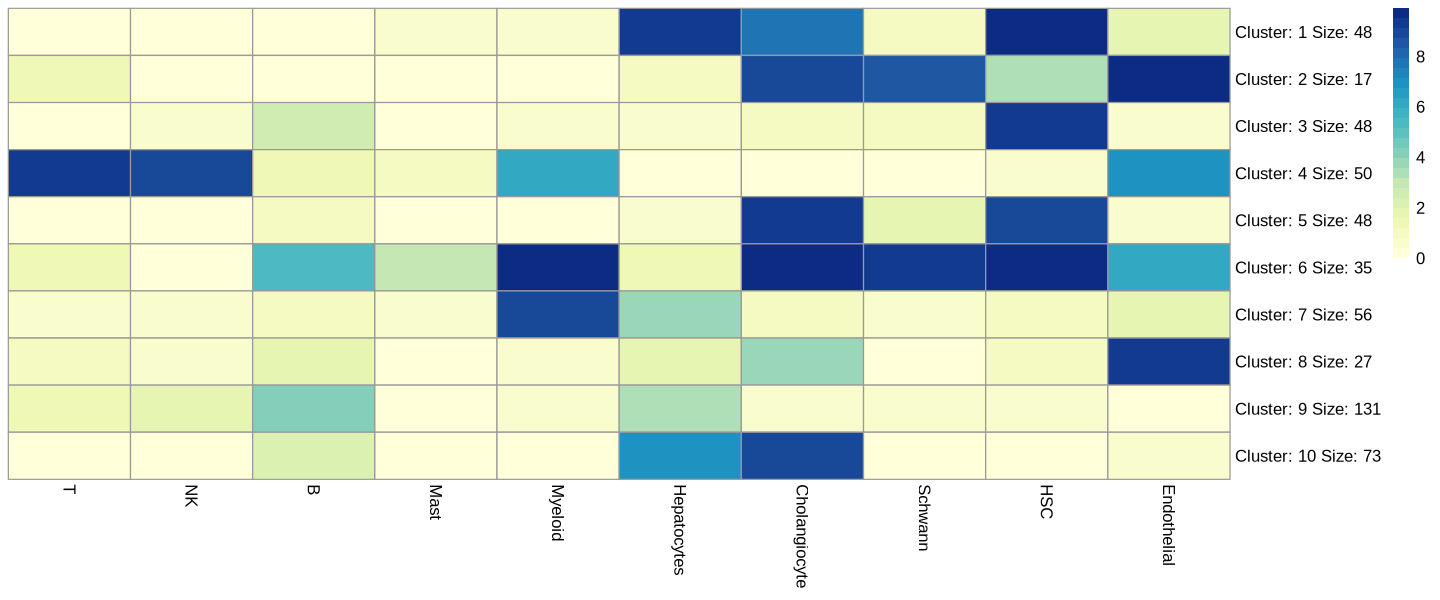

In [163]:
set.seed(921)
t1 <- smat %>%
pheatmap(scale = "none", cluster_rows = F, cluster_cols = F, kmeans_k = 10, 
         color = colorRampPalette(brewer.pal(n = 8, name = "YlGnBu"))(25))

Using celltype as id variables



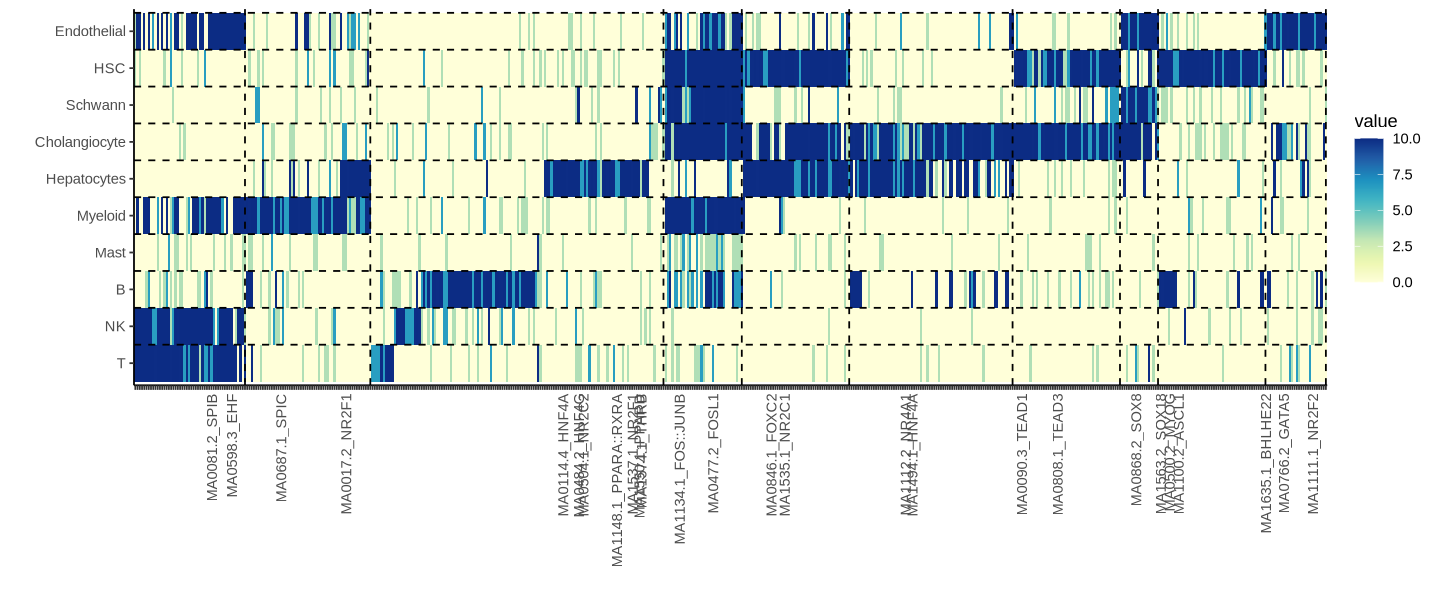

In [168]:
rorder <- t1$kmeans$cluster %>% as.data.frame %>% setNames("cluster") %>%
mutate(cluster = factor(cluster, levels = c(4, 7, 9, 6, 1, 10, 5, 2, 3, 8))) %>%
arrange(cluster)

ttp <- smat[rownames(rorder),] %>% t %>% as.data.frame %>% 
tibble::rownames_to_column("celltype") %>%
reshape2::melt() %>%
mutate(celltype = factor(celltype, levels = corder)) %>%
mutate(variable = factor(variable, levels = rownames(rorder)))

vltp <- table(rorder$cluster) %>%
as.data.frame %>%
select(Freq) %>% unlist %>% cumsum

llabel <- merge(ffile, rorder, by.x = "motif", by.y = 0) %>%
group_by(cluster) %>% 
slice_min(order_by = log10(p_value), n = 2) %>% ungroup %>%
mutate(celltype = factor(celltype, levels = corder)) %>%
select(motif) %>% unlist %>% unique

llabel <- grep(paste0(llabel, collapse = "|"), unique(ttp$variable), value = T) %>% as.character
labs.row <- unique(ttp$variable) %>% as.character
labs.row[!((labs.row) %in% llabel)] <- ""
# ttp$label = ttp$variable %>% as.character
# ttp$label[!(ttp$label %in% llabel)] <- ""

t2 <- ttp %>%
ggplot(aes(x = variable, y = celltype, fill = value)) + 
geom_tile() + ylab("") + xlab("") + 
geom_hline(yintercept = seq(1.5, length(unique(ttp$celltype)) + 0.5, by = 1),  # Add lines between rows
           linetype = "dashed", color = "black") +
geom_vline(xintercept = vltp, linetype = "dashed", color = "black") +
theme_classic() + 
scale_x_discrete(labels = labs.row) + 
# geom_text_repel(aes(label = labs.row), size = 3) +  # Use ggrepel to position labels
# scale_x_continuous(breaks = ttp$variable) +  # Ensure x-axis ticks match
theme(axis.text.x = element_text(angle = 90, hjust = 1)) + 
scale_fill_gradientn(colours = colorRampPalette(brewer.pal(n = 8, name = "YlGnBu"))(25))

t2

## GO term

In [39]:
pw <- read.csv("../reference/241224_WE_ct_specific_links/fGSEA/All_fGSEA.fora_GO.BP_specific_links.tsv", sep = '\t') %>%
filter(padj < 0.05)

pw %>% select(cell) %>% table

cell
            B Cholangiocyte   Endothelial   Hepatocytes           HSC 
           52            85           152           281            18 
      Myeloid 
          683 

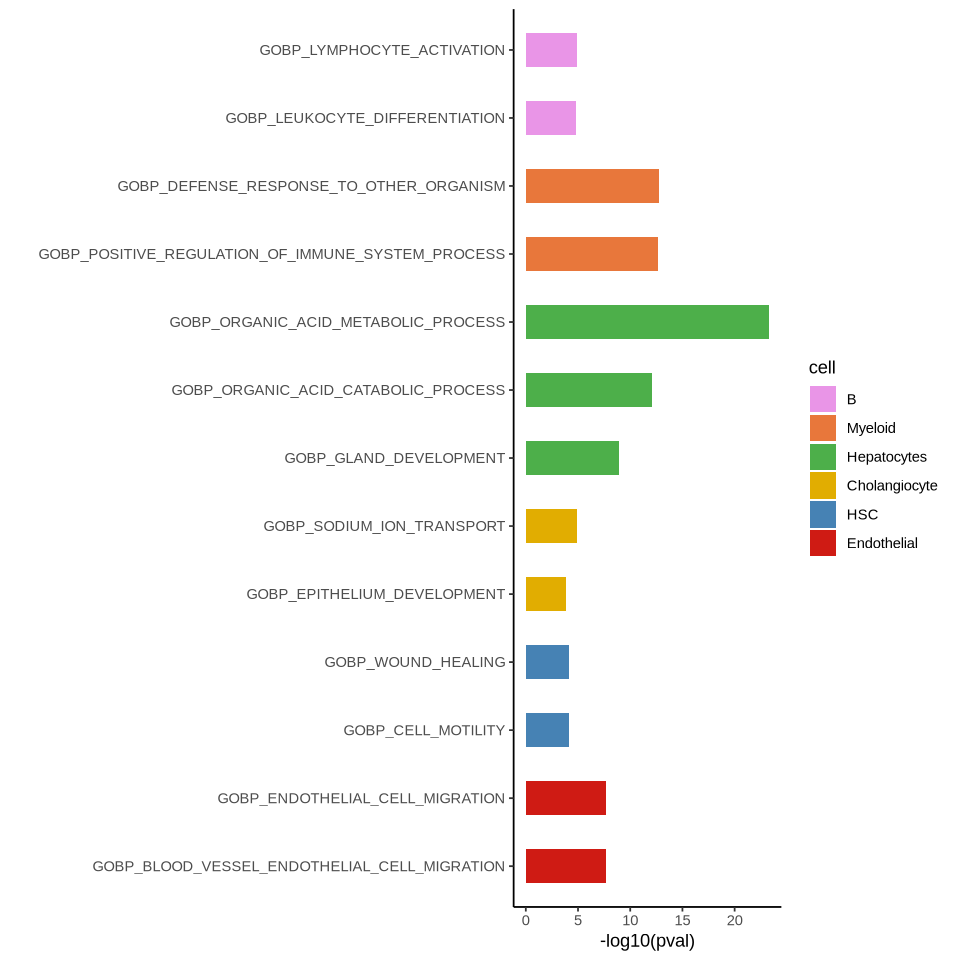

In [54]:
### Select marker to plot
qpw <- read.table("All_fGSEA.fora_GO.BP_specific_links.filt.txt", header = T)

torder <- rbind(qpw, qterm) %>% 
filter(pathway != "GOBP_SODIUM_ION_TRANSMEMBRANE_TRANSPORT") %>%
mutate(cell = factor(cell, levels = corder)) %>%
arrange(cell) %>% select(pathway) %>% unlist %>% as.character

options(repr.plot.width = 8, repr.plot.height = 8)
t1 <- rbind(qpw, qterm) %>%
filter(pathway != "GOBP_SODIUM_ION_TRANSMEMBRANE_TRANSPORT") %>%
mutate(cell = factor(cell, levels = corder)) %>%
mutate(pathway = factor(pathway, levels = rev(torder))) %>%
ggplot(aes(y = pathway, x = -log10(pval), fill = cell)) + 
geom_col(width = 0.5) + 
# geom_point(aes(size = -log10(Adjusted.P.value)), color = "#036EB8") + 
# scale_size(range = c(3, 8)) + 
theme_classic() + ylab("") + 
scale_fill_manual(values = celltype_colors) + 
scale_y_discrete(labels = label_wrap(30))

t1

ggsave(t1, filename = "plot/FIG_cts_links_genes_fGSEA.pdf", dpi = 300, height = 8, width = 8)

## Output fragments for chromHMM

In [9]:
rmeta <- read.table("FNIH_DPT_clustering/FNIH_Liver_pool_DPT_SNG_SoupX_reference_mapping_filtered.new.meta.xls",
                   header = T, sep = "\t")
mts <- rmeta %>% mutate(cluster = paste0(predicted.celltype, "_", Target)) %>%
select(c(dna, dna_bc, cluster)) %>%
setNames(c("library", "barcode", "cluster")) %>%
mutate(sample = paste0(library, "_fragments.tsv.gz"))

write.table(mts, "chromhmm/fragment.cluster_info.txt", sep = "\t", quote = F, row.names = F, col.names = T)

In [35]:
refmeta <- read.table("../reference/Final_fNIH_Liver_10X_Multiome_meta.xls", header = T, sep = "\t")
refmeta$barcode <- lapply(stringr::str_split(rownames(refmeta), pattern = "_"), function(x) x[length(x)]) %>% unlist
  
mts <- refmeta %>% mutate(cluster = paste0(celltype, "_ATAC")) %>%
select(c(library, barcode, cluster)) %>%
setNames(c("library", "barcode", "cluster")) %>%
mutate(sample = paste0(library, ".atac_fragments.tsv.gz"))

write.table(mts, "chromhmm/atac_fragment.cluster_info.txt", sep = "\t", quote = F, row.names = F, col.names = T)

In [49]:
mts <- mmg@meta.data %>%
mutate(sample = paste0("FNIH_Liver_", predicted.celltype, "_", Target, ".bed")) %>% 
mutate(cluster = paste0(predicted.celltype, "_", Target, "_", condition)) %>%
select(c(dna, dna_bc, cluster, sample)) %>%
setNames(c("library", "barcode", "cluster", "sample")) 

write.table(mts, "chromhmm/disease_bed/fragment.cluster_info.txt", sep = "\t", quote = F, row.names = F, col.names = T)

refmeta <- read.table("../reference/Final_fNIH_Liver_10X_Multiome_meta.xls", header = T, sep = "\t")
donor_info <- read.table("../reference/Donor_condition.xls")
refmeta$condition <- donor_info[match(refmeta$donor_demux, donor_info$donor_demux),]$condition
refmeta$barcode <- lapply(stringr::str_split(rownames(refmeta), pattern = "_"), function(x) x[length(x)]) %>% unlist
refmeta$barcode <- paste0(refmeta$library, ":", refmeta$barcode)
                          
mts <- refmeta %>% 
mutate(sample = paste0("FNIH_Liver_", celltype, "_ATAC.bed")) %>% 
mutate(cluster = paste0(celltype, "_ATAC_", condition)) %>%
select(c(library, barcode, cluster, sample)) %>%
setNames(c("library", "barcode", "cluster", "sample")) 

write.table(mts, "chromhmm/disease_bed/atac_fragment.cluster_info.txt", sep = "\t", quote = F, row.names = F, col.names = T)

### Read chromHMM results

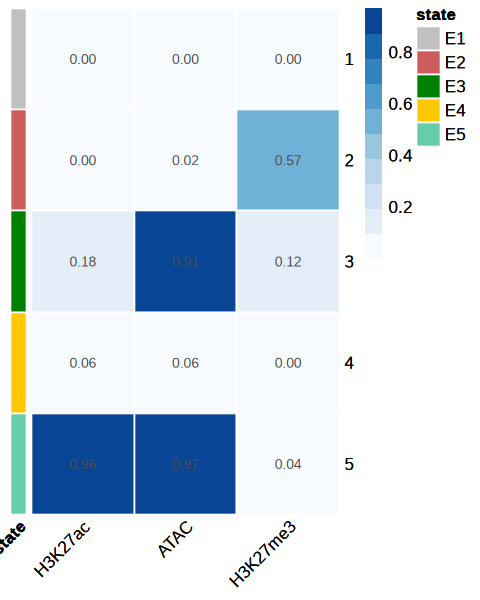

In [25]:
chmstate <- read.table("chromhmm/output/bin200_5/emissions_5.txt", sep = "\t", header = T, row.names = 1)

canno <- data.frame(state = paste0("E", 1:5))
rownames(canno) <- rownames(chmstate)
cols <- c("#c0c0c0", "#cd5c5c","#008000", "#ffc800", '#66cdaa')
names(cols) <- c("E1", "E2", "E3", "E4", "E5")

options(repr.plot.width = 4, repr.plot.height = 5)
t1 <- chmstate %>% 
pheatmap(cluster_rows = F, cluster_cols = F, scale = "none", angle_col = 45, display_numbers = T,
         annotation_row = canno, annotation_colors = list(state = cols),
         border_color = "white", show_rownames = T, show_colnames = T,
         color = colorRampPalette(brewer.pal(n = 8, name = "Blues"))(10))

t1

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


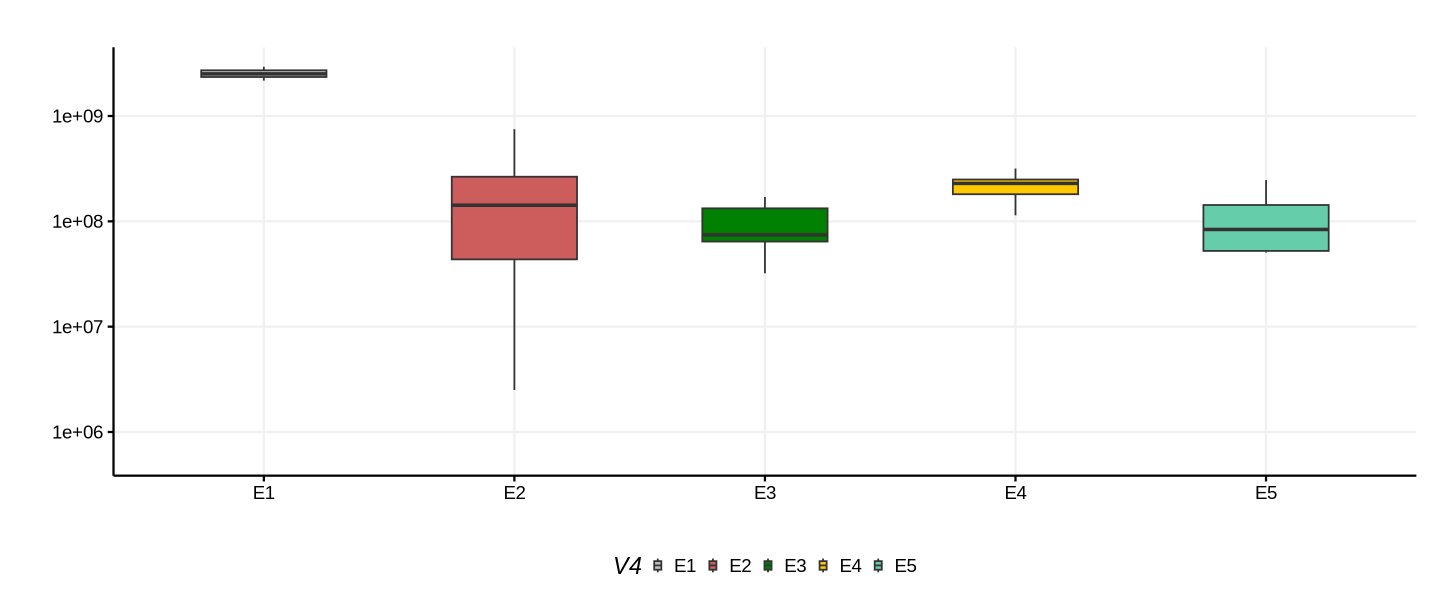

In [131]:
### Genome coverage?
chmm <- list()
for (f in list.files("chromhmm/output/bin200_5/", pattern = ".*_5_segments.bed.gz")){
    fname = gsub("_5_segments.bed.gz", "", f)
    chmm[[f]] <- read.table(paste0("chromhmm/output/bin200_5/", f)) %>% 
    mutate(length = V3 - V2) %>%
    group_by(V4) %>%
    summarise(size = sum(length)) %>%
    ungroup() %>%
    mutate(celltype = fname)
}

t1 <- do.call(rbind, chmm) %>%
ggplot(aes(x = V4, y = size, fill = V4)) + 
# stat_boxplot(geom ='errorbar') + 
geom_boxplot(width = 0.5, position = position_dodge(0.7), coef = 2, outlier.shape = NA) +
theme_Publication() + scale_y_log10() + 
scale_fill_manual(values = cols) +
xlab("") + ylab("")

t1
ggsave(t1, filename = "plot/FIG_chromhmm_coverage.pdf", dpi = 300, height = 4, width = 4)

Using V4 as id variables

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


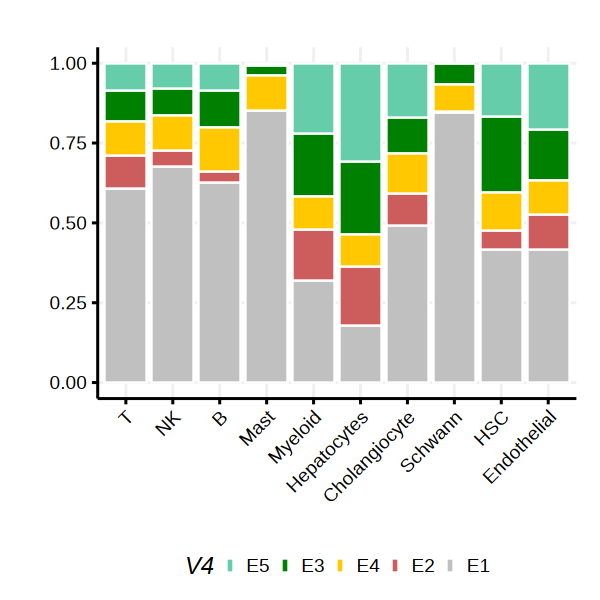

In [34]:
t1 <- apply(chmm, MARGIN = 2, table) %>%
as.data.frame %>% tibble::rownames_to_column("V4") %>%
mutate(V4 = paste0("E", V4)) %>%
reshape2::melt() %>%
mutate(V4 = factor(as.character(V4), levels = c("E5", "E3", "E4", "E2", "E1"))) %>%
mutate(variable = factor(variable, levels = corder)) %>%
ggplot(aes(x = variable, y = value, fill = V4)) + 
geom_col(color = "white", position = "fill") +
theme_Publication() + 
scale_fill_manual(values = cols) +
xlab("") + ylab("") + 
theme(axis.text.x = element_text(angle = 45, hjust = 1))

options(repr.plot.width = 5, repr.plot.height = 5)
t1

## Plot ChromHMM states in Hepatocytes

In [4]:
suppressPackageStartupMessages(library(ggalluvial))

chmm <- list()
for (f in list.files("chromhmm/annotate/", pattern = "^Liver_UnionPeak_*.*_annotate.bed")){
    fname = gsub("_annotate.bed", "", f)
    chmm[[f]] <- read.table(paste0("chromhmm/annotate/", f)) %>% 
    mutate(range = paste0(V1, ":", V2, "-", V3)) %>%
    select(c(range, V4)) %>% 
    group_by(range) %>%
    slice_sample(n = 1) %>%
    ungroup() %>%
    tibble::column_to_rownames("range") %>% setNames(fname)
}
commonf <- Reduce(intersect, lapply(chmm, rownames))
for (f in names(chmm)){
    chmm[[f]] <- chmm[[f]][commonf, , drop = F]
}
chmm <- Reduce(cbind, chmm[-1], chmm[[1]]) ### dont use do.call for cbind

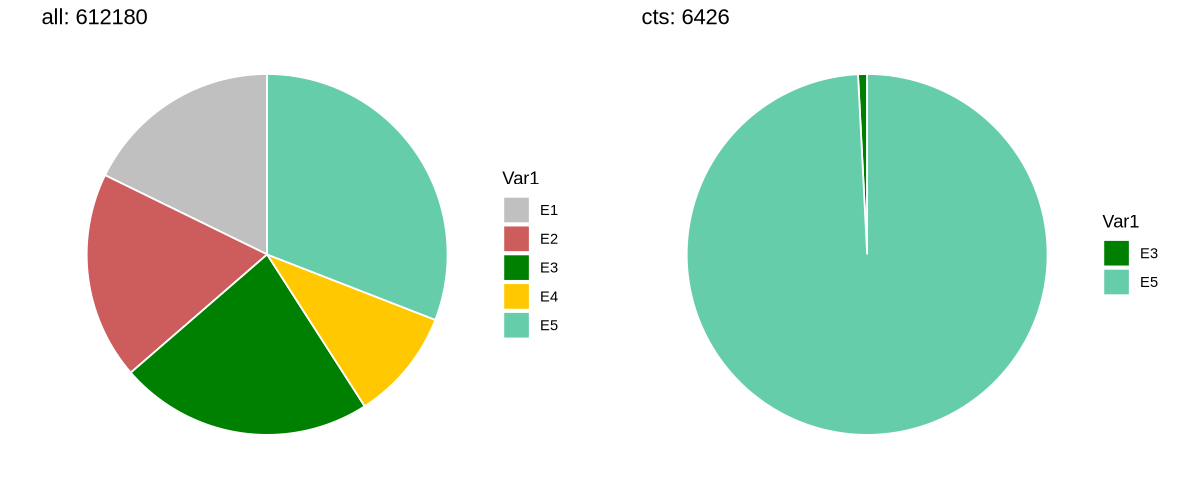

In [763]:
chmm <- read.table("chromhmm/annotate/Liver_UnionPeak_Hepatocytes_annotate.bed") %>% mutate(range = paste0(V1, "-", V2, "-", V3))
t1 <- table(chmm[, 'V4']) %>%
as.data.frame %>% setNames(c("Var1", "ct")) %>% filter(Var1 != ".") %>%
mutate(Var1 = as.character(Var1)) %>%
ggplot(aes(x = "", y = ct, fill = Var1)) + 
geom_bar(stat = "identity", position = position_fill(), color = "white") + 
coord_polar(theta = "y") + theme_void() + 
scale_fill_manual(values = cols) + 
ggtitle(paste0("all: ", nrow(chmm)))

qpaek <- cts[cts$celltype == "Hepatocytes", ]$peaks
t2 <- chmm[chmm$range %in% qpaek, "V4"] %>% table %>%
as.data.frame %>% setNames(c("Var1", "ct")) %>% filter(Var1 != ".") %>%
mutate(Var1 = as.character(Var1)) %>%
ggplot(aes(x = "", y = ct, fill = Var1)) + 
geom_bar(stat = "identity", position = position_fill(), color = "white") + 
coord_polar(theta = "y") + theme_void() + 
scale_fill_manual(values = cols) + 
ggtitle(paste0("cts: ", length(qpaek)))

fig1 <- cowplot::plot_grid(t1, t2, ncol = 2)

fig1
# ggsave(fig1, filename = "plot/FIG_Hepatocytes_chromhmm_elements.pdf", dpi = 300, height = 4, width = 8)

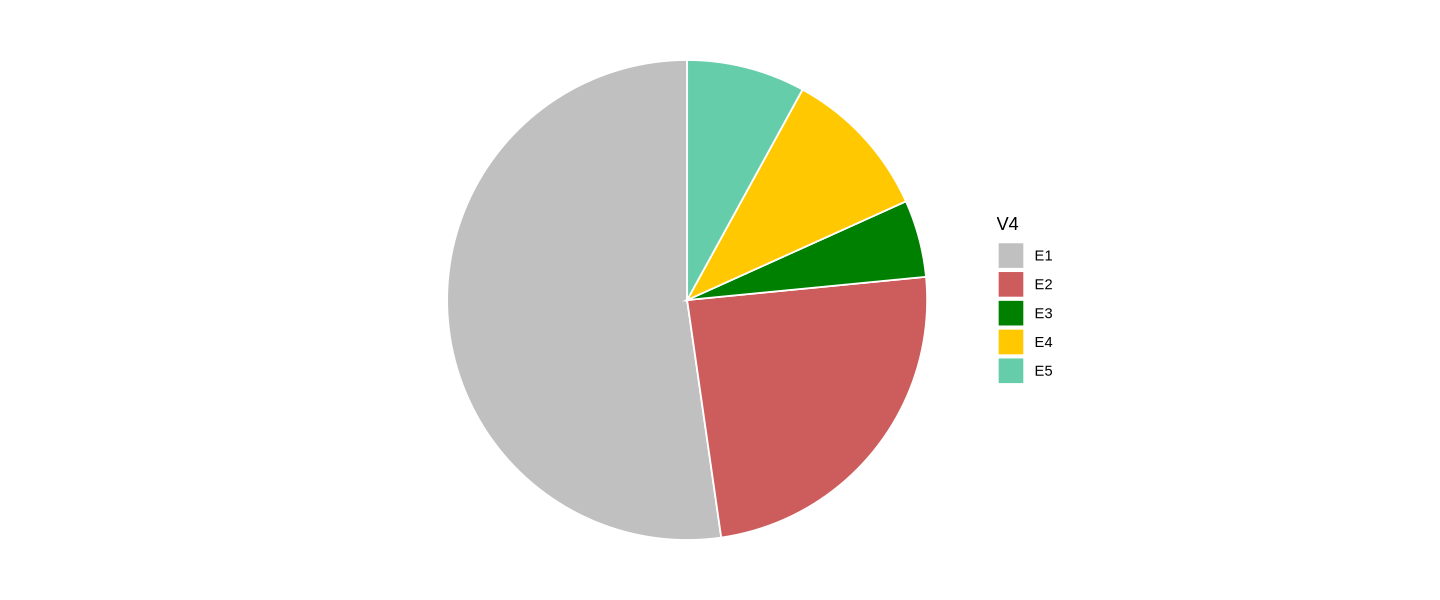

In [136]:
### Plot exmaple: hepa
t1 <- chmm[[grep("Hepa", names(chmm), value = T)]] %>%
ggplot(aes(x = "", y = size, fill = V4)) +
geom_bar(width = 1, stat = "identity", color = "white") +
coord_polar(theta = "y") + 
theme_void() + 
scale_fill_manual(values = cols)

t1
ggsave(t1, filename = "plot/FIG_Hepatocytes_chromhmm_genome_coverage.pdf", dpi = 300, height = 4, width = 4)

`summarise()` has grouped output by 'V4'. You can override using the `.groups` argument.


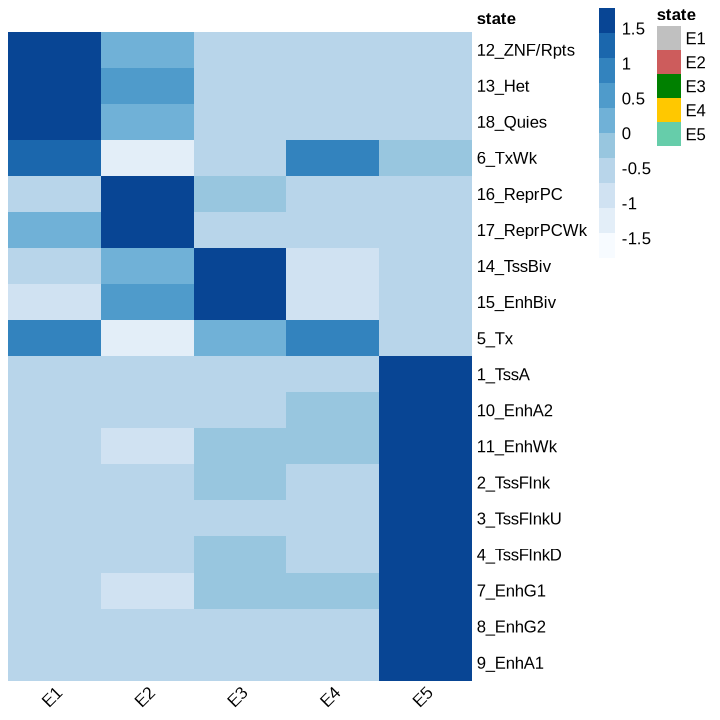

In [293]:
### Compare with epigenome roadmap?
#  zcat bin200_5/Hepatocytes_5_segments.bed.gz |bedtools intersect -wao -a - -b /projects/ps-renlab2/y2xie/projects/public_data/17.Epigenome_roadmap/mnemonics/E066_18_core_K27ac_mnemonics.hg38.bed > Hepatocytes_5_segments_ovlp_066_18_core_K27ac_mnemonics.hg38.bed
scomp <- read.table("/projects/ps-renlab2/y2xie/projects/77.LC/78.FNIH_DPT_IGM_240813/05.R/chromhmm/output/Hepatocytes_5_segments_ovlp_066_18_core_K27ac_mnemonics.hg38.bed")

scompp <- scomp[,c("V4", "V8", "V9")] %>%
group_by(V4, V8) %>%
summarise(leng = sum(V9)) %>%
filter(V8 != ".") %>%
reshape2::dcast(V4 ~ V8, value.var = "leng") %>%
tibble::column_to_rownames("V4") 

scompp[is.na(scompp)] <- 0
rmat <- t(scompp) # (scompp / rowSums(scompp)) %>% t
max_indices <- max.col(rmat)
permutation_vector <- order(max_indices)
smat <- rmat[(permutation_vector),]
t1 <- smat %>%
pheatmap(scale = "row", cluster_rows = F, cluster_cols = F, angle_col = 45,
         show_rownames = T, show_colnames = T, border_color = NA, 
         annotation_col = canno, annotation_colors = list(state = cols),
         color = colorRampPalette(brewer.pal(n = 8, name = "Blues"))(10))

ggsave(t1, filename = "plot/FIG_Hepatocytes_chromhmm_overlap_w_roadmap.pdf", dpi = 300, height = 7, width = 4)

`summarise()` has grouped output by 'V4'. You can override using the `.groups` argument.


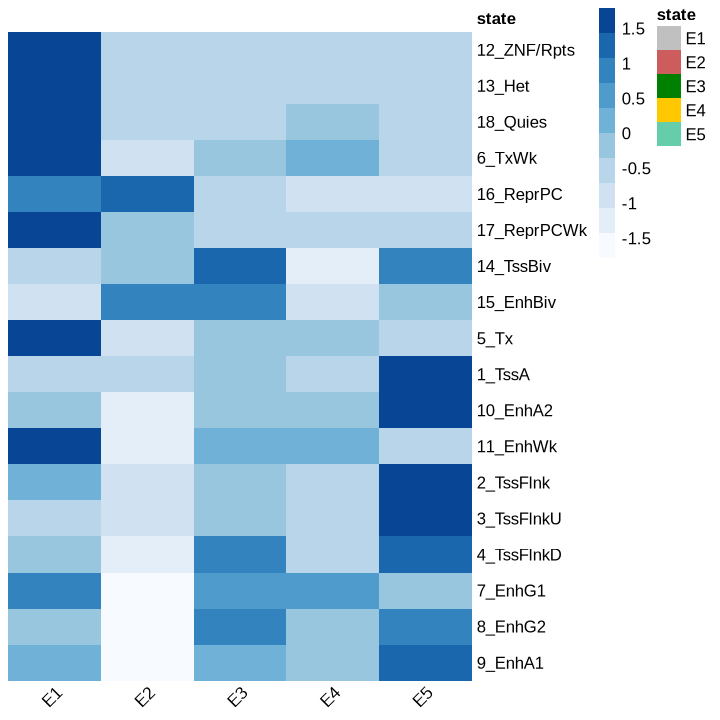

In [294]:
### what if...
scomp <- read.table("/projects/ps-renlab2/y2xie/projects/77.LC/78.FNIH_DPT_IGM_240813/05.R/chromhmm/output/HSC_5_segments_ovlp_066_18_core_K27ac_mnemonics.hg38.bed")

scompp <- scomp[,c("V4", "V8", "V9")] %>%
group_by(V4, V8) %>%
summarise(leng = sum(V9)) %>%
filter(V8 != ".") %>%
reshape2::dcast(V4 ~ V8, value.var = "leng") %>%
tibble::column_to_rownames("V4") 

scompp[is.na(scompp)] <- 0
rmat <- t(scompp) # (scompp / rowSums(scompp)) %>% t
smat1 <- rmat[rownames(smat),]
t2 <- smat1 %>%
pheatmap(scale = "row", cluster_rows = F, cluster_cols = F, angle_col = 45,
         show_rownames = T, show_colnames = T, border_color = NA, 
         annotation_col = canno, annotation_colors = list(state = cols),
         color = colorRampPalette(brewer.pal(n = 8, name = "Blues"))(10))

ggsave(t2, filename = "plot/FIG_HSC_chromhmm_overlap_w_roadmap.pdf", dpi = 300, height = 7, width = 4)

## Plot ChromHMM states CTR vs MASL

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


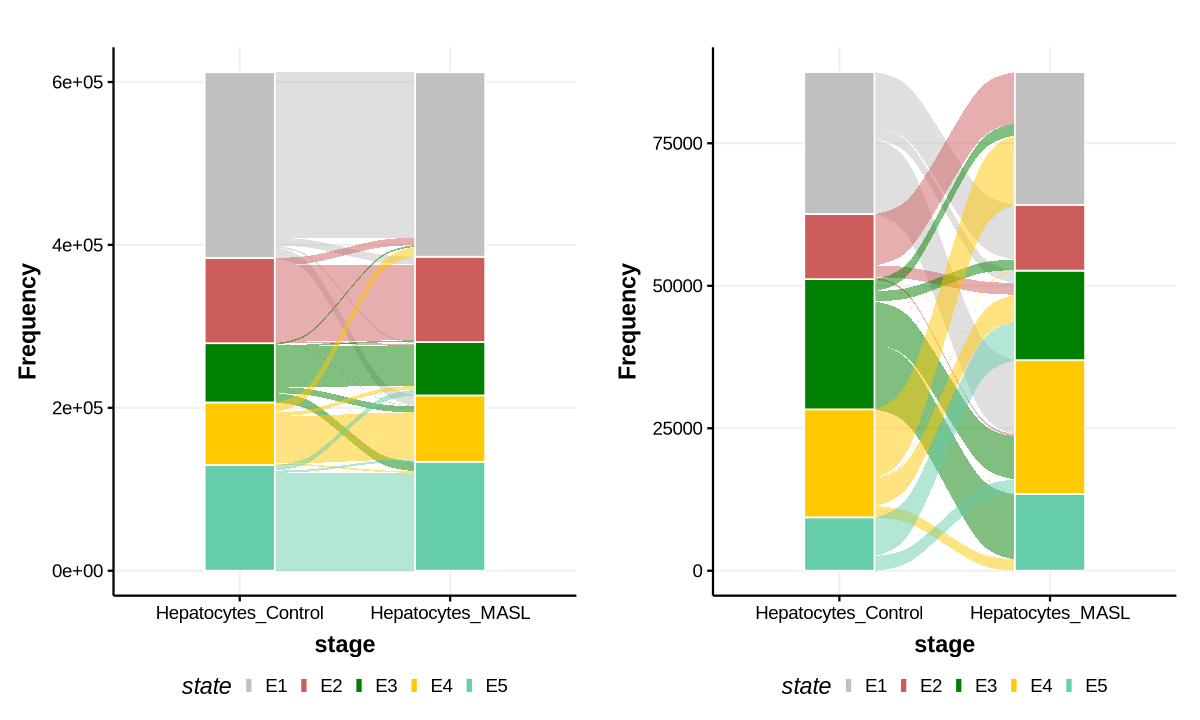

In [357]:
### There are many elements with states switched desipte low number of DE peaks
options(repr.plot.width = 10, repr.plot.height = 6)
qry <- chmm[,c(1,3)] 
data <- qry %>% count(!!!syms(colnames(qry))) %>% arrange(desc(n))
data$id <- 1:nrow(data)
t1 <- data %>% tidyr::pivot_longer(cols = starts_with("Hepa"), names_to = "stage", values_to = "state") %>%
ggplot(aes(x = stage, stratum = state, alluvium = id, y = n, fill = state)) +
geom_flow() + ylab("Frequency") + 
geom_stratum(color = "white") +
theme_Publication() + 
scale_fill_manual(values = cols)

qry <- chmm[chmm[,1] != chmm[,3],c(1,3)] 
data <- qry %>% count(!!!syms(colnames(qry))) %>% arrange(desc(n))
data$id <- 1:nrow(data)
t2 <- data %>% tidyr::pivot_longer(cols = starts_with("Hepa"), names_to = "stage", values_to = "state") %>%
ggplot(aes(x = stage, stratum = state, alluvium = id, y = n, fill = state)) +
geom_flow() + ylab("Frequency") + 
geom_stratum(color = "white") +
theme_Publication() + 
scale_fill_manual(values = cols)

fig1 <- cowplot::plot_grid(t1, t2, ncol = 2)
fig1

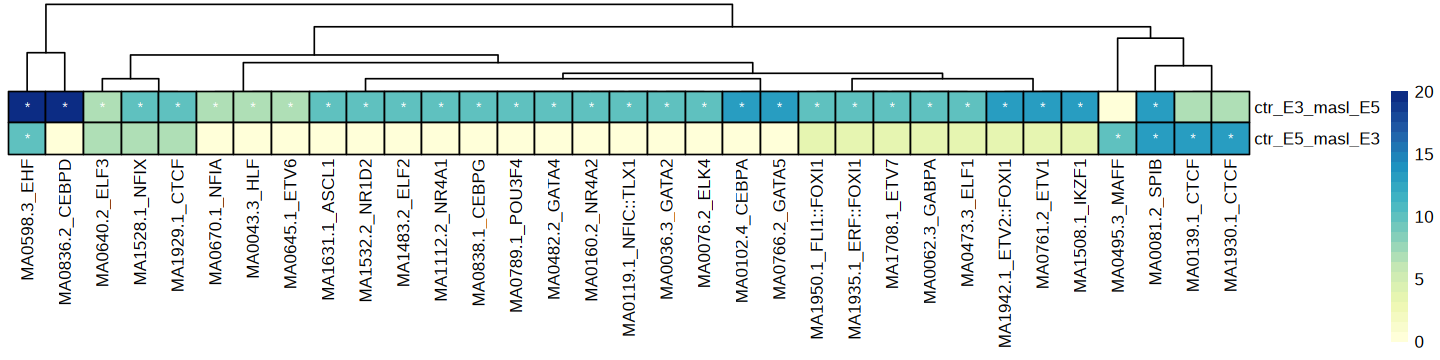

In [34]:
### Compare CTR / MASL motif enrichment
mlist <- list()
for (f in list.files("chromhmm/motif/")){
    mlist[[f]] <- read.csv(paste0("chromhmm/motif/", f, "/knownResults.txt"), sep = "\t") %>%
    setNames(c('motif', 'Consensus', 'p_value', 'Log_Pvalue', 'fdr', "target_num", "target_pct", "bgd_num", "bgd_pct")) %>%
    mutate(group = f)
}
vmotif <- do.call(rbind, mlist) %>%
group_by(motif) %>% 
filter(min(fdr) < 0.05) %>% ungroup() %>%
dplyr::select(motif) %>% unlist %>% unique

motif <- do.call(rbind, mlist) %>%
filter(motif %in% vmotif) %>%
reshape2::dcast(group ~ motif, value.var = "p_value", fun.aggregate = mean) %>%
tibble::column_to_rownames("group") 
motif[is.na(motif)] <- 1
motif <- -log2(motif)
motif[motif > 20] <- 20

lmat <- do.call(rbind, mlist) %>% 
mutate(value = fdr) %>%
reshape2::dcast(group ~ motif, value.var = "value", fun.aggregate = mean) %>%
tibble::column_to_rownames("group") 

lmat[is.na(lmat)] <- 1
lmat <- ifelse(lmat < 0.05, "*", "")

options(repr.plot.width = 12, repr.plot.height = 3)
t1 <- motif %>% 
pheatmap(scale = "none", cluster_rows = F, cluster_cols = T, angle_col = 90, border_color = "black", 
         show_rownames = T, display_number = lmat[rownames(motif), colnames(motif)], number_color = "white", # labels_row = labs.row,
         color = colorRampPalette(brewer.pal(n = 8, name = "YlGnBu"))(25))

## Visualize disease associated regions in hepatocyte

In [36]:
### Hepatocytes
### fibrosis
atac <- read.table("../reference/ATAC_by_celltype_fibrosis.241130.cpm.txt", header = T, row.names = 1)
k27ac <- read.csv("FNIH_DPT_signal/FNIH_Liver_pool.H3K27ac_celltype_fibrosis.LiverUnionPeaks.cpm.csv", row.names = 1)
k27me3 <- read.csv("FNIH_DPT_signal/FNIH_Liver_pool.H3K27me3_celltype_fibrosis.LiverUnionPeaks.cpm.csv", row.names = 1)
ffeature <- read.table("../reference/241025_ATAC_Gaulton_Peaks_DESeq/Hepatocytes_Fibrosis.stage.dds.res") %>% filter(padj < 0.05)

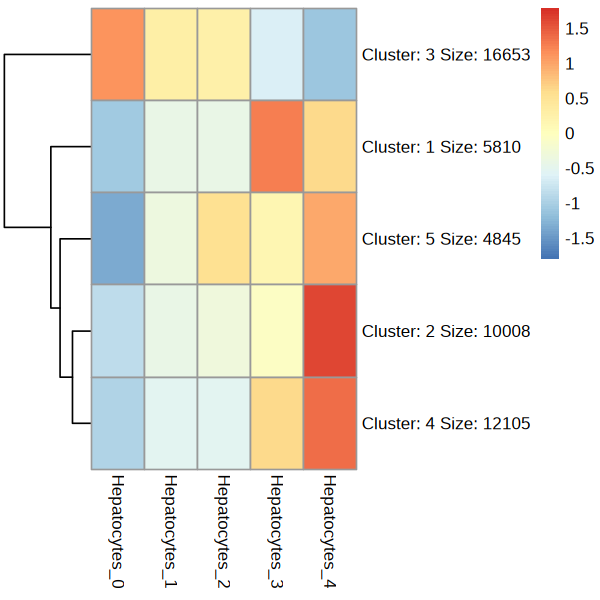

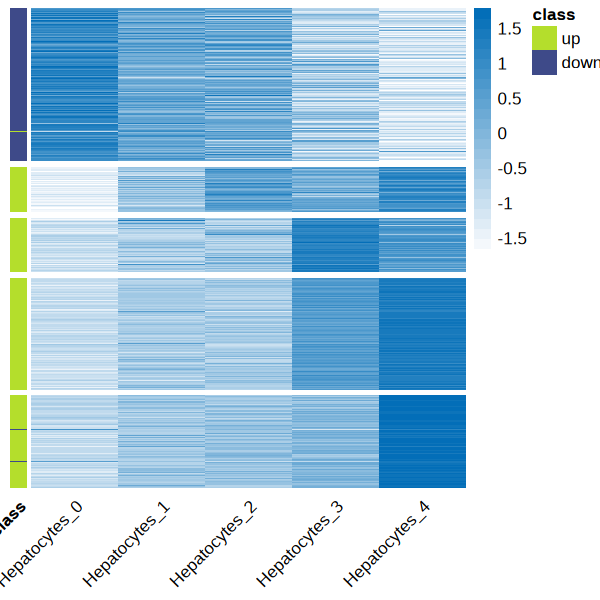

In [37]:
ct <- "Hepatocytes"
set.seed(921)
canno <- ffeature %>%
mutate(class = ifelse(log2FoldChange > 0, "up", "down")) %>% 
select(class)
ccolor <- list("class" = c(up = viridis(10)[9], down = viridis(10)[3]))

t1 <- atac[intersect(rownames(atac), rownames(ffeature)), sort(grep(ct, colnames(atac), value = T))] %>%
pheatmap(scale = "row", cluster_cols = F, show_rownames = T, kmeans_k = 5)

kname <- t1$kmeans$cluster %>% as.data.frame %>%
setNames("k") %>%
mutate(k = factor(k, levels = c(3,5,1,4,2))) %>%
arrange(k)

t1 <- atac[rownames(kname), sort(grep(ct, colnames(atac), value = T))] %>%
pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, show_rownames = F, 
         gaps_row = cumsum(table(kname$k)),
         annotation_row = canno, annotation_colors = ccolor,
         border_color = "white", color = colorRampPalette(c("white", "#036EB8"))(25))

In [927]:
kname[,c("chrom", "start", "end")] <- stringr::str_split_fixed(rownames(kname), pattern = "-", n = 3)
write.table(kname[,c("chrom", "start", "end", "k")], "ATAC_Fibrosis_depeak_kmeans5.txt", sep = '\t', quote = F, 
            row.names = F, col.names = F)

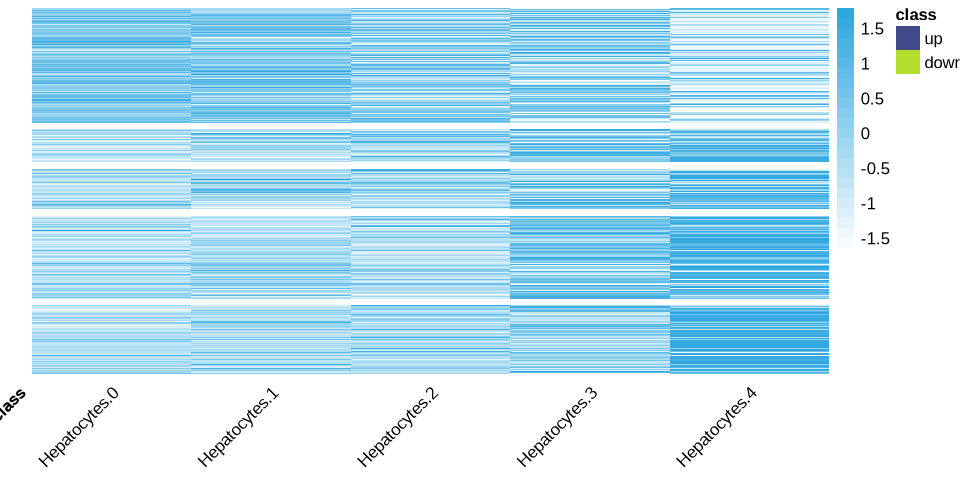

In [898]:
tmp <- log2(k27ac[sub("-", ":", rownames(kname)), sort(grep(ct, colnames(k27ac), value = T))]+1)
t2 <- tmp %>% pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, show_rownames = F,
               gaps_row = cumsum(table(kname$k)),
               annotation_row = canno, annotation_colors = ccolor,
               border_color = "white", color = colorRampPalette(c("white", "#2EA7E0"))(25))

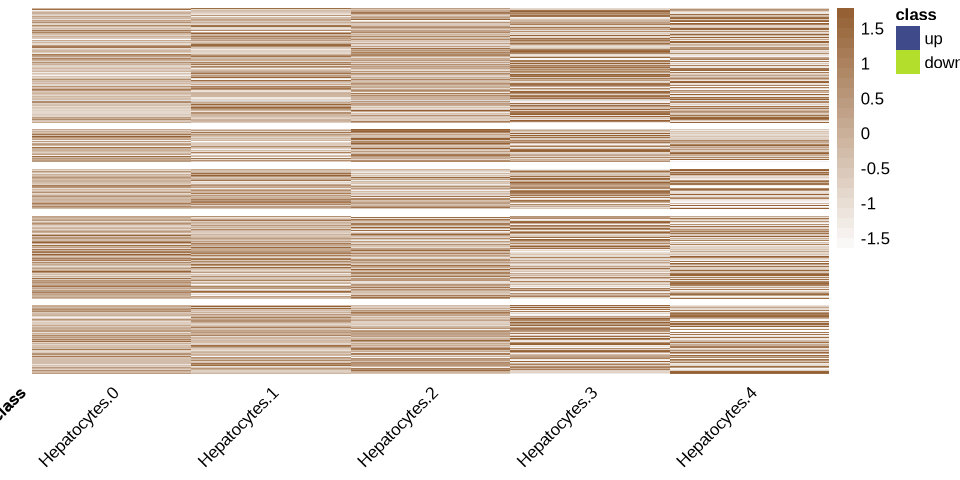

In [900]:
tmp <- log2(k27me3[sub("-", ":", rownames(kname)), sort(grep(ct, colnames(k27me3), value = T))]+1) 
# tmp[tmp > 4] <- 4
# tmp[tmp < 0.5] <- 0

t3 <- tmp %>%
pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, show_rownames = F,
         gaps_row = cumsum(table(kname$k)),
         annotation_row = canno, annotation_colors = ccolor,
         border_color = "white", color = colorRampPalette(c("white", "#956134"))(25))

### Also try including chromatin states

In [40]:
chmm <- list()
for (f in list.files("chromhmm/fibrosis_annotate/", pattern = "^Liver_UnionPeak_Hepatocytes*.*_annotate.bed")){
    fname = gsub("_annotate.bed", "", f)
    chmm[[f]] <- read.table(paste0("chromhmm/fibrosis_annotate/", f)) %>% 
    mutate(range = paste0(V1, ":", V2, "-", V3)) %>%
    select(c(range, V4)) %>% 
    group_by(range) %>%
    slice_sample(n = 1) %>%
    ungroup() %>%
    tibble::column_to_rownames("range") %>% setNames(fname)
}
commonf <- Reduce(intersect, lapply(chmm, rownames))
for (f in names(chmm)){
    chmm[[f]] <- chmm[[f]][commonf, , drop = F]
}
chmm <- Reduce(cbind, chmm[-1], chmm[[1]]) ### dont use do.call for cbind
colnames(chmm) <- gsub("Liver_UnionPeak_", "", colnames(chmm))

In [44]:
suppressPackageStartupMessages(library(ggalluvial))
plist <- list()
for (f in unique(kname$k)){
    qpeak <- kname %>% filter(k == f) %>% rownames()
    data <- chmm[sub("-", ":", qpeak), ]
    data <- data %>% count(!!!syms(colnames(data))) %>% arrange(desc(n))
    data$id <- 1:nrow(data)
    plist[[paste0("k", f)]] <- data %>% 
    tidyr::pivot_longer(cols = starts_with("Hepa"), names_to = "stage", values_to = "state") %>%
#     mutate(stage = factor(stage, levels = paste0("Hepatocytes_", c("Control", "MASL", "MASH-low", "MASH-high")))) %>%
    arrange(desc(stage)) %>%
    ggplot(aes(x = stage, stratum = state, alluvium = id, y = n, fill = state)) +
    geom_flow() + ylab("Frequency") + 
    geom_stratum(color = "white") +
    theme_Publication() + ggtitle(paste0("k", f)) +
    scale_fill_manual(values = cols)
}

options(repr.plot.width = 8, repr.plot.height = 6)
fig1 <- cowplot::plot_grid(plotlist = plist, ncol = 3)

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


In [46]:
ggsave(fig1, filename = "plot/FIG_ATAC_MASH-Fib_depeak_chromhmm.pdf", dpi = 300, height = 8, width = 12)

In [84]:
# atac <- read.table("../reference/ATAC_by_celltype_fibrosis.241130.cpm.txt", header = T, row.names = 1)
cols3 <- colorRampPalette(brewer.pal(n = 9, name = "YlGn"))(6)[2:6]; names(cols3) <- 0:4

plist <- list()
for (f in unique(kname$k)){
    qpeak <- kname %>% filter(k == f) %>% rownames()
    data <- atac[qpeak, grep("Hepa", colnames(atac))]
    colnames(data) <- gsub("Hepatocytes_", "", colnames(data))
    plist[[paste0("k", f)]] <- data %>% 
    reshape2::melt() %>%
    mutate(variable = factor(variable, levels = as.character(0:4))) %>%
    ggplot(aes(x = variable, y = value+1, fill = variable)) +
    geom_boxplot(width = 0.5, position = position_dodge(0.7), coef = 2, outlier.shape = NA) +
    theme_Publication() + ggtitle(paste0("k", f)) +
    scale_y_log10() + 
    scale_fill_manual(values = cols3)
}

options(repr.plot.width = 8, repr.plot.height = 6)
fig1 <- cowplot::plot_grid(plotlist = plist, ncol = 3)

No id variables; using all as measure variables

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
No id variables; using all as measure variables

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
No id variables; using all as measure variables

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
No id variables; using all as measure variables

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
No id variables; using all as measure variables

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


In [86]:
ggsave(fig1, filename = "plot/FIG_ATAC_MASH-Fib_depeak_ATAC_cpm.pdf", dpi = 300, height = 8, width = 12)

In [935]:
### Hepatocytes
### disease
atac <- read.table("../reference/ATAC_by_celltype_disease.241130.cpm.txt", header = T, row.names = 1)
k27ac <- read.csv("FNIH_DPT_signal/FNIH_Liver_pool.H3K27ac_celltype_disease.LiverUnionPeaks.cpm.csv", row.names = 1)
k27me3 <- read.csv("FNIH_DPT_signal/FNIH_Liver_pool.H3K27me3_celltype_disease.LiverUnionPeaks.cpm.csv", row.names = 1)
ffeature <- read.table("../reference/241025_ATAC_Gaulton_Peaks_DESeq/Hepatocytes_MetALD_vs_Control.dds.res") %>% filter(padj < 0.05)

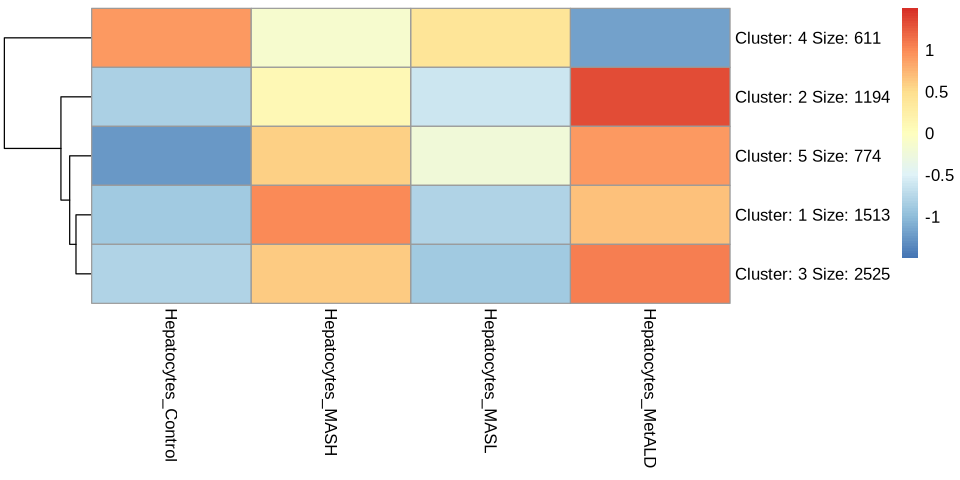

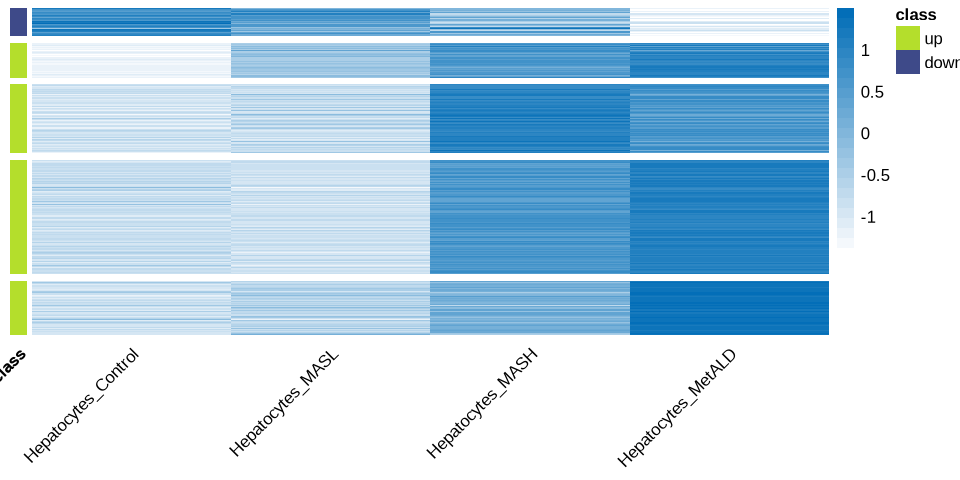

In [911]:
set.seed(921)
canno <- ffeature %>%
mutate(class = ifelse(log2FoldChange > 0, "up", "down")) %>% 
select(class)
ccolor <- list("class" = c(up = viridis(10)[9], down = viridis(10)[3]))

t1 <- atac[intersect(rownames(atac), rownames(ffeature)), sort(grep(ct, colnames(atac), value = T))] %>%
pheatmap(scale = "row", cluster_cols = F, show_rownames = T, kmeans_k = 5)

kname <- t1$kmeans$cluster %>% as.data.frame %>%
setNames("k") %>%
mutate(k = factor(k, levels = c(4,5,1,3,2))) %>%
arrange(k)

t1 <- atac[rownames(kname), paste0(ct, c("_Control", "_MASL", "_MASH", "_MetALD"))] %>%
pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, show_rownames = F, 
         gaps_row = cumsum(table(kname$k)),
         annotation_row = canno, annotation_colors = ccolor,
         border_color = "white", color = colorRampPalette(c("white", "#036EB8"))(25))

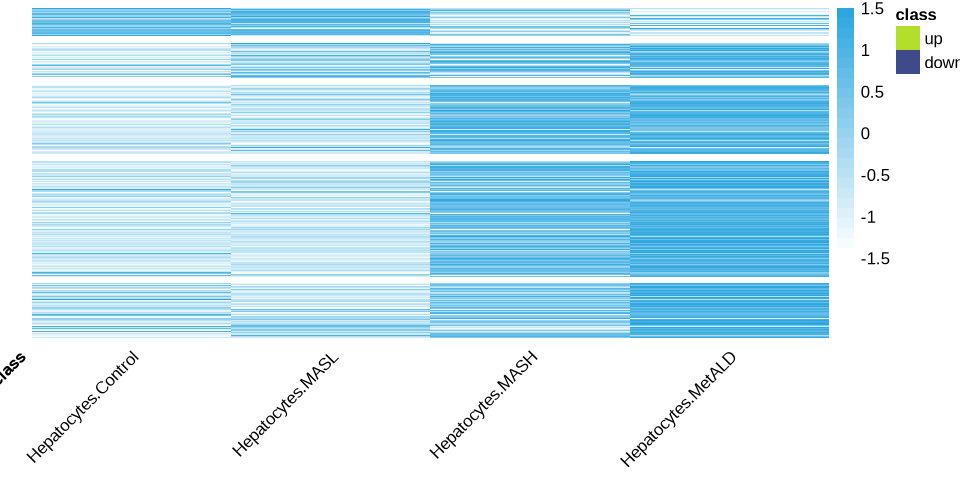

In [913]:
tmp <- log2(k27ac[sub("-", ":", rownames(kname)), paste0(ct, c(".Control", ".MASL", ".MASH", ".MetALD"))]+1)
t2 <- tmp %>% pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, show_rownames = F,
               gaps_row = cumsum(table(kname$k)),
               annotation_row = canno, annotation_colors = ccolor,
               border_color = "white", color = colorRampPalette(c("white", "#2EA7E0"))(25))

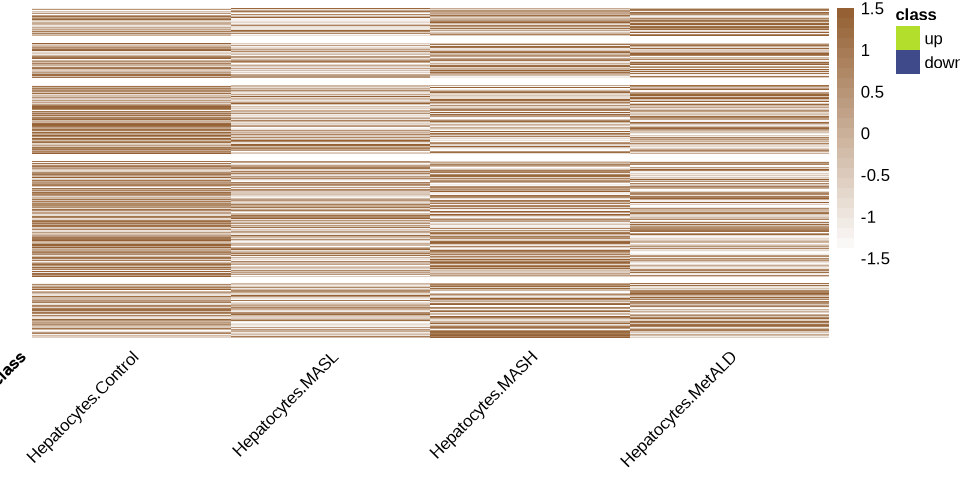

In [914]:
tmp <- log2(k27me3[sub("-", ":", rownames(kname)), paste0(ct, c(".Control", ".MASL", ".MASH", ".MetALD"))]+1) 

t3 <- tmp %>%
pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, show_rownames = F,
         gaps_row = cumsum(table(kname$k)),
         annotation_row = canno, annotation_colors = ccolor,
         border_color = "white", color = colorRampPalette(c("white", "#956134"))(25))

In [915]:
ggsave(t1, filename = "plot/FIG_ATAC_MetALD_depeak.png", dpi = 300, height = 7, width = 4)
ggsave(t2, filename = "plot/FIG_H3K27ac_MetALD_depeak.png", dpi = 300, height = 7, width = 4)
ggsave(t3, filename = "plot/FIG_H3K27me3_MetALD_depeak.png", dpi = 300, height = 7, width = 4)

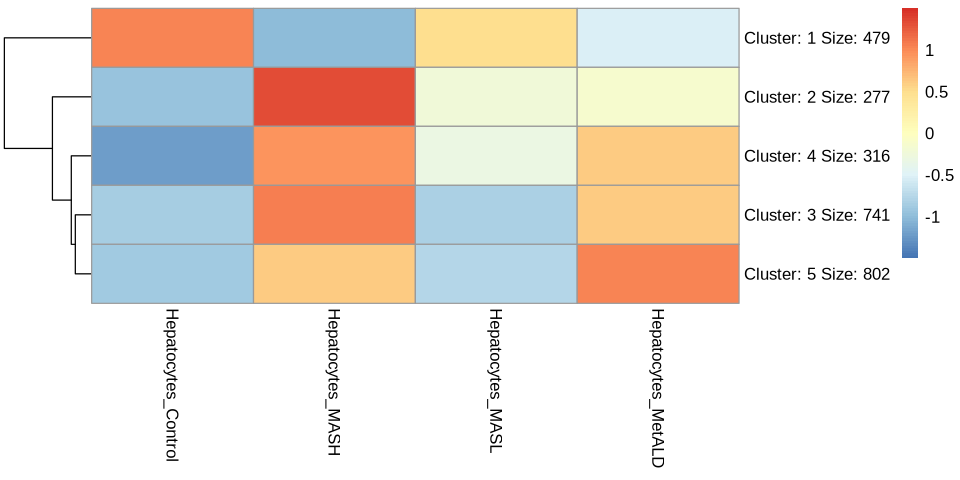

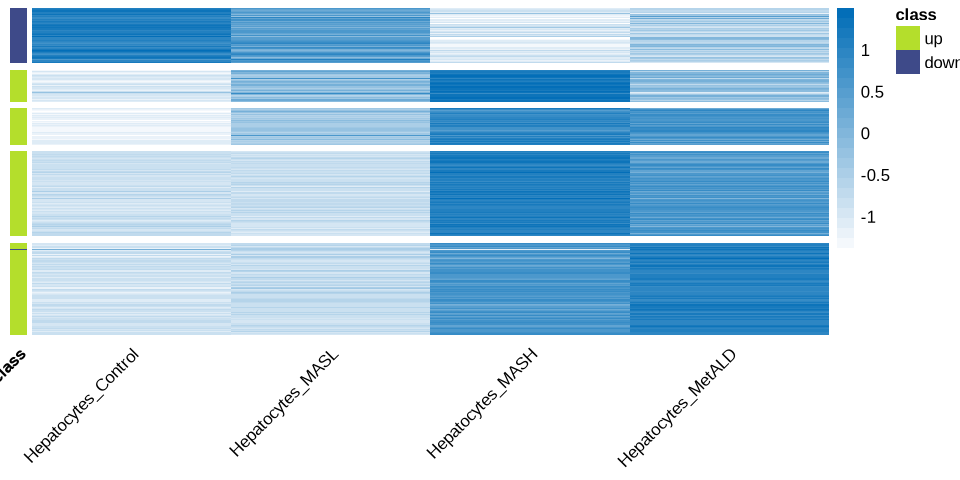

In [936]:
ffeature1 <- read.table("../reference/241025_ATAC_Gaulton_Peaks_DESeq/Hepatocytes_MASH_vs_Control.dds.res") %>% filter(padj < 0.05)

set.seed(921)
canno <- ffeature1 %>%
mutate(class = ifelse(log2FoldChange > 0, "up", "down")) %>% 
select(class)
ccolor <- list("class" = c(up = viridis(10)[9], down = viridis(10)[3]))

t1 <- atac[intersect(rownames(atac), rownames(ffeature1)), sort(grep(ct, colnames(atac), value = T))] %>%
pheatmap(scale = "row", cluster_cols = F, show_rownames = T, kmeans_k = 5)

kname <- t1$kmeans$cluster %>% as.data.frame %>%
setNames("k") %>%
mutate(k = factor(k, levels = c(1,2,4,3,5))) %>%
arrange(k)

t1 <- atac[rownames(kname), paste0(ct, c("_Control", "_MASL", "_MASH", "_MetALD"))] %>%
pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, show_rownames = F, 
         gaps_row = cumsum(table(kname$k)),
         annotation_row = canno, annotation_colors = ccolor,
         border_color = "white", color = colorRampPalette(c("white", "#036EB8"))(25))

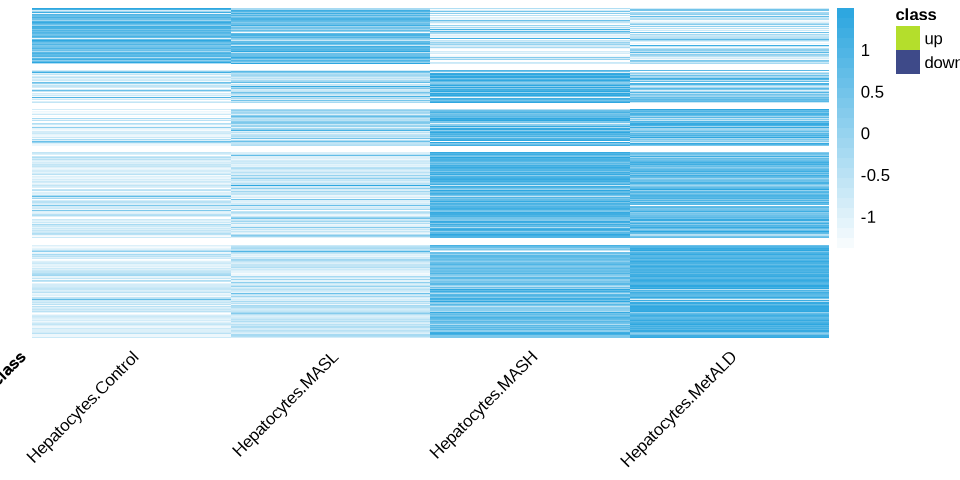

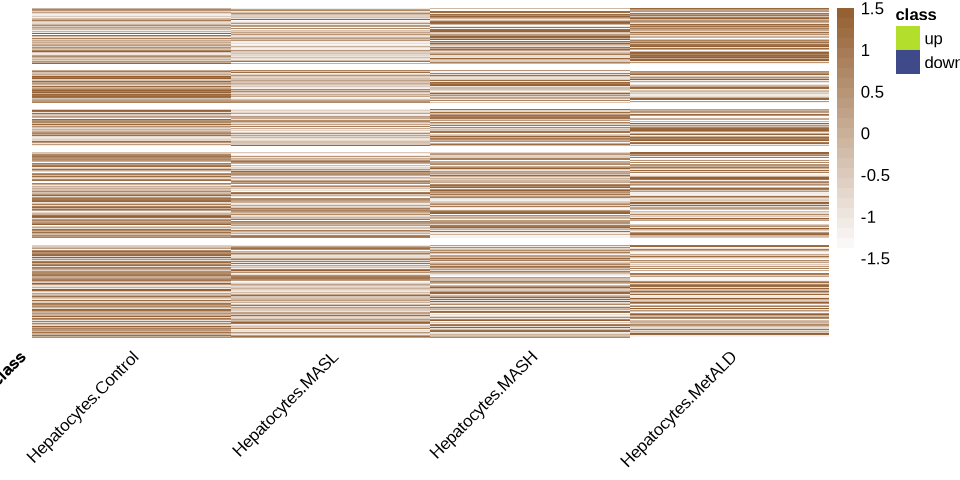

In [919]:
tmp <- log2(k27ac[sub("-", ":", rownames(kname)), paste0(ct, c(".Control", ".MASL", ".MASH", ".MetALD"))]+1)
t2 <- tmp %>% pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, show_rownames = F,
               gaps_row = cumsum(table(kname$k)),
               annotation_row = canno, annotation_colors = ccolor,
               border_color = "white", color = colorRampPalette(c("white", "#2EA7E0"))(25))

tmp <- log2(k27me3[sub("-", ":", rownames(kname)), paste0(ct, c(".Control", ".MASL", ".MASH", ".MetALD"))]+1) 

t3 <- tmp %>%
pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, show_rownames = F,
         gaps_row = cumsum(table(kname$k)),
         annotation_row = canno, annotation_colors = ccolor,
         border_color = "white", color = colorRampPalette(c("white", "#956134"))(25))

### Use fib +/- for classification

In [35]:
k27ac <- read.csv('FNIH_DPT_signal/FNIH_Liver_pool.H3K27ac_celltype_disease2.LiverUnionPeaks.cpm.csv', row.names = 1)
k27me3 <- read.csv('FNIH_DPT_signal/FNIH_Liver_pool.H3K27me3_celltype_disease2.LiverUnionPeaks.cpm.csv', row.names = 1)
atac <- read.csv('FNIH_DPT_signal/FNIH_Liver_pool.ATAC_celltype_disease2.LiverUnionPeaks.cpm.csv', row.names = 1)

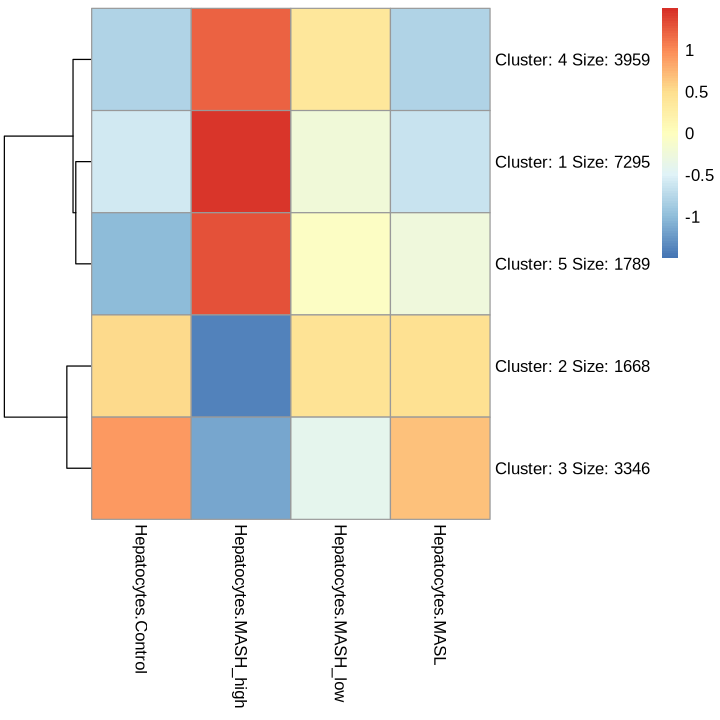

In [136]:
ct <- "Hepatocytes"
ffeature1 <- read.table(paste0("../reference/250216_Low_High_Fibrosis_ATAC_DESeq/", ct, "_High_Fibrosis_vs_Control.dds.res")) %>% 
filter(padj < 0.05)

set.seed(921)
canno <- ffeature1 %>%
mutate(class = ifelse(log2FoldChange > 0, "up", "down")) %>% 
select(class)
ccolor <- list("class" = c(up = viridis(10)[9], down = viridis(10)[3]))

f1 <- atac[intersect(rownames(atac), rownames(ffeature1)), sort(grep(ct, colnames(atac), value = T))] %>%
pheatmap(scale = "row", cluster_cols = F, show_rownames = T, kmeans_k = 5)

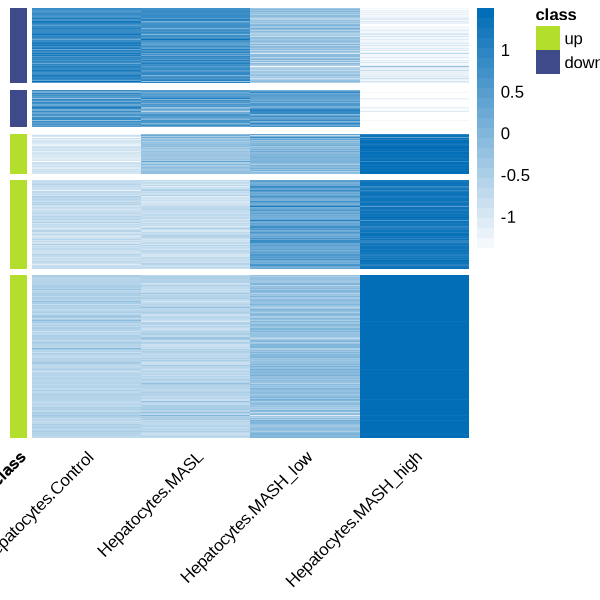

In [222]:
kname <- f1$kmeans$cluster %>% as.data.frame %>%
setNames("k") %>%
mutate(k = factor(k, levels = c(3,2,5,4,1))) %>%
arrange(k)

options(repr.plot.width = 5, repr.plot.height = 5)
t1 <- atac[rownames(kname), paste0(ct, c(".Control", ".MASL", ".MASH_low", ".MASH_high"))] %>%
pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, show_rownames = F, 
         gaps_row = cumsum(table(kname$k)),
         annotation_row = canno, annotation_colors = ccolor,
         border_color = "white", color = colorRampPalette(c("white", "#036EB8"))(25))

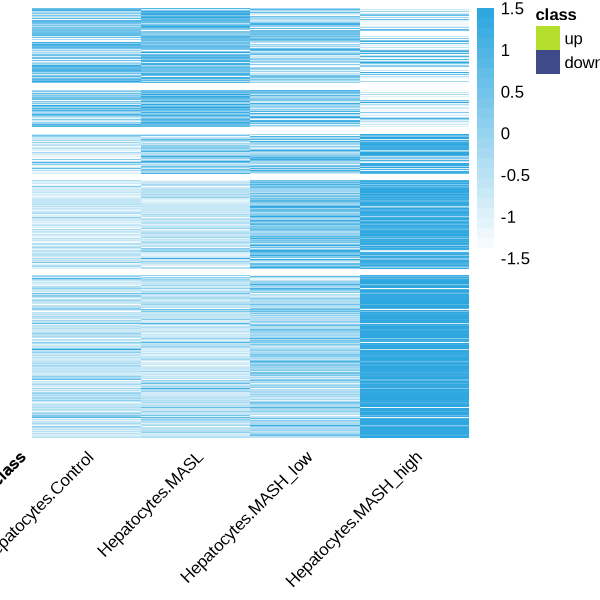

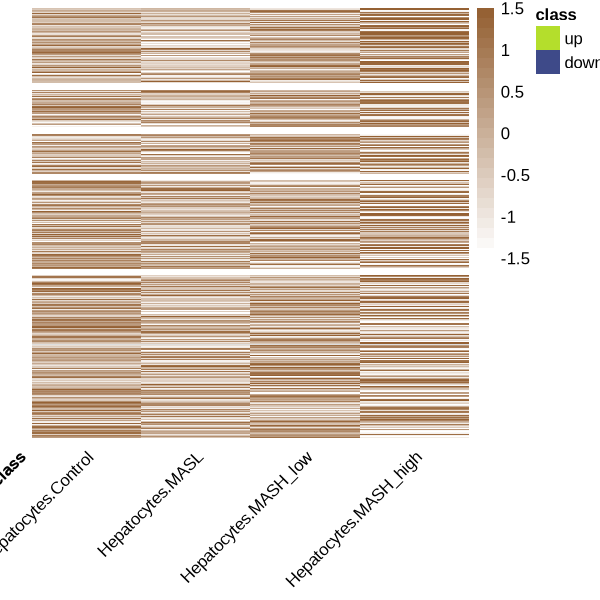

In [223]:
options(repr.plot.width = 5, repr.plot.height = 5)
tmp <- log2(k27ac[sub("-", ":", rownames(kname)), paste0(ct, c(".Control", ".MASL", ".MASH_low", ".MASH_high"))]+1)
t2 <- tmp %>% pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, show_rownames = F,
               gaps_row = cumsum(table(kname$k)),
               annotation_row = canno, annotation_colors = ccolor,
               border_color = "white", color = colorRampPalette(c("white", "#2EA7E0"))(25))

tmp <- log2(k27me3[sub("-", ":", rownames(kname)), paste0(ct, c(".Control", ".MASL", ".MASH_low", ".MASH_high"))]+1) 
t3 <- tmp %>%
pheatmap(scale = "row",cluster_rows = F, cluster_cols = F, angle_col = 45, show_rownames = F,
         gaps_row = cumsum(table(kname$k)),
         annotation_row = canno, annotation_colors = ccolor,
         border_color = "white", color = colorRampPalette(c("white", "#956134"))(25))

### Also check chromatin states

In [15]:
suppressPackageStartupMessages(library(ggalluvial))

chmm <- list()
for (f in list.files("chromhmm/disease_annotate/", pattern = "^Liver_UnionPeak_Hepatocytes*.*_annotate.bed")){
    fname = gsub("_annotate.bed", "", f)
    chmm[[f]] <- read.table(paste0("chromhmm/disease_annotate/", f)) %>% 
    mutate(range = paste0(V1, ":", V2, "-", V3)) %>%
    select(c(range, V4)) %>% 
    group_by(range) %>%
    slice_sample(n = 1) %>%
    ungroup() %>%
    tibble::column_to_rownames("range") %>% setNames(fname)
}
commonf <- Reduce(intersect, lapply(chmm, rownames))
for (f in names(chmm)){
    chmm[[f]] <- chmm[[f]][commonf, , drop = F]
}
chmm <- Reduce(cbind, chmm[-1], chmm[[1]]) ### dont use do.call for cbind
colnames(chmm) <- gsub("Liver_UnionPeak_", "", colnames(chmm))
head(chmm)

,Hepatocytes_Control,Hepatocytes_MASH,Hepatocytes_MASH-high,Hepatocytes_MASH-low,Hepatocytes_MASL,Hepatocytes_MetALD
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
chr10:100000179-100000479,E4,E4,E4,E3,E4,E4
chr10:100001764-100002064,E4,E4,E3,E3,E5,E4
chr10:100006358-100006658,E5,E5,E5,E5,E5,E5
chr10:100009803-100010103,E5,E5,E5,E5,E5,E5
chr10:100014254-100014554,E1,E4,E4,E1,E1,E1
chr10:100020228-100020528,E3,E3,E3,E3,E3,E3


In [228]:
cols <- c("#c0c0c0", "#cd5c5c","#008000", "#ffc800", '#66cdaa')
names(cols) <- c("E1", "E2", "E3", "E4", "E5")

plist <- list()
for (f in unique(kname$k)){
    qpeak <- kname %>% filter(k == f) %>% rownames()
    data <- chmm[sub("-", ":", qpeak), grep(paste0(c("Control", "MASL", "MASH-low", "MASH-high"), collapse = "|"), colnames(chmm))]
    data <- data %>% count(!!!syms(colnames(data))) %>% arrange(desc(n))
    data$id <- 1:nrow(data)
    plist[[paste0("k", f)]] <- data %>% 
    tidyr::pivot_longer(cols = starts_with("Hepa"), names_to = "stage", values_to = "state") %>%
    mutate(stage = factor(stage, levels = paste0("Hepatocytes_", c("Control", "MASL", "MASH-low", "MASH-high")))) %>%
    arrange(desc(stage)) %>%
    ggplot(aes(x = stage, stratum = state, alluvium = id, y = n, fill = state)) +
    geom_flow() + ylab("Frequency") + 
    geom_stratum(color = "white") +
    theme_Publication() + ggtitle(paste0("k", f)) +
    scale_fill_manual(values = cols)
}

options(repr.plot.width = 8, repr.plot.height = 6)
fig1 <- cowplot::plot_grid(plotlist = plist, ncol = 3)

Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”
Warning message:
“`legend.margin` must be specified using `margin()`
ℹ For the old behavior use `legend.spacing`”


## Export each kmeans module for motif finding

In [145]:
system('mkdir -p motif/ATAC_MASH-fib_depeak')
for (f in unique(kname$k)){
    tmp <- kname %>% filter(k == f) %>% rownames
    tmp <- stringr::str_split_fixed(tmp, pattern = "-", n = 3)
    write.table(tmp, paste0("motif/ATAC_MASH-fib_depeak/k", f, ".bed"), sep = "\t", 
                quote = F, row.names = F, col.names = F)
}

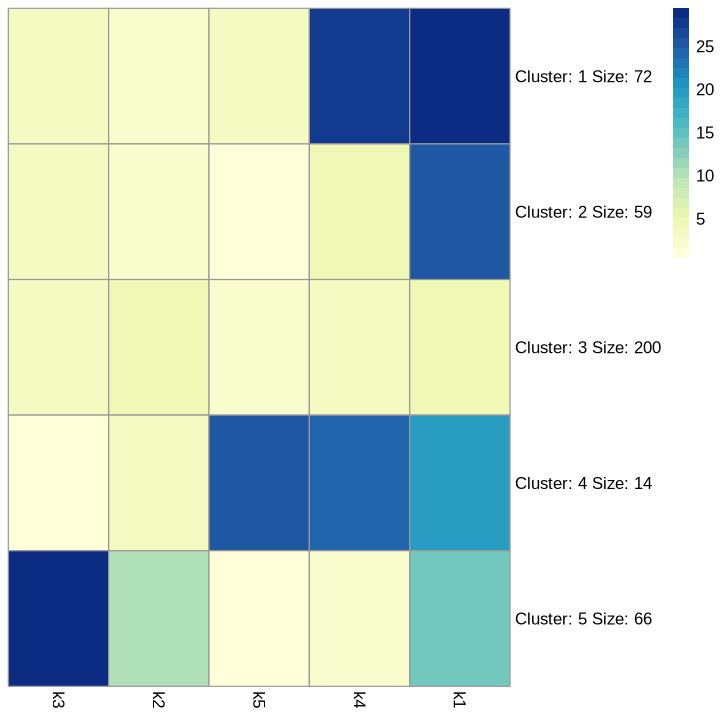

In [117]:
motif <- list()
for (f in list.files("motif/ATAC_MASH-fib_depeak/", pattern = ".*.bed")){
    fname <- gsub(".bed", "", f)
    motif[[fname]] <- read.csv(paste0("motif/ATAC_MASH-fib_depeak/", fname, "/knownResults.txt"), sep = "\t") %>%
    setNames(c("motif", "consensus", "p_value", "log_p_value", "fdr", "tgt_num", "tgt_pct", "bgd_num", "bgd_pct")) %>%
    mutate(celltype = fname)
}

ffile <- do.call(rbind, motif)

vmotif <- do.call(rbind, motif) %>% group_by(motif) %>% 
filter(min(fdr) < 0.05) %>% ungroup() %>%
select(motif) %>% unlist %>% unique

motif <- do.call(rbind, motif) %>%
filter(motif %in% vmotif) %>%
reshape2::dcast(celltype ~ motif, value.var = "p_value") %>%
tibble::column_to_rownames("celltype") %>% t
motif[is.na(motif)] <- 1
motif <- -log2(motif)
motif[motif > 30] <- 30

rmat <- motif[, paste0("k", c(3,2,5,4,1))]
max_indices <- max.col(rmat)
permutation_vector <- order(max_indices)
smat <- rmat[permutation_vector, ]

set.seed(921)
t1 <- smat %>%
pheatmap(scale = "none", cluster_rows = F, cluster_cols = F, kmeans_k = 5, 
         color = colorRampPalette(brewer.pal(n = 8, name = "YlGnBu"))(25))

In [118]:
rorder <- t1$kmeans$cluster %>% as.data.frame %>% setNames("cluster") %>%
mutate(cluster = factor(cluster, levels = c(5,4,3,1,2))) %>%
arrange(cluster)

ttp <- smat[rownames(rorder),] %>% t %>% as.data.frame %>% 
tibble::rownames_to_column("celltype") %>%
reshape2::melt() %>%
mutate(celltype = factor(celltype, levels = paste0("k", c(3,2,5,4,1)))) %>%
mutate(variable = factor(variable, levels = rownames(rorder)))

vltp <- table(rorder$cluster) %>%
as.data.frame %>%
select(Freq) %>% unlist %>% cumsum

llabel <- merge(ffile, rorder, by.x = "motif", by.y = 0) %>%
group_by(cluster) %>% 
slice_min(order_by = log10(p_value), n = 2) %>% ungroup %>%
mutate(celltype = factor(celltype, levels = corder)) %>%
select(motif) %>% unlist %>% unique

llabel <- grep(paste0(llabel, collapse = "|"), unique(ttp$variable), value = T) %>% as.character
labs.row <- unique(ttp$variable) %>% as.character
labs.row[!((labs.row) %in% llabel)] <- ""

Using celltype as id variables



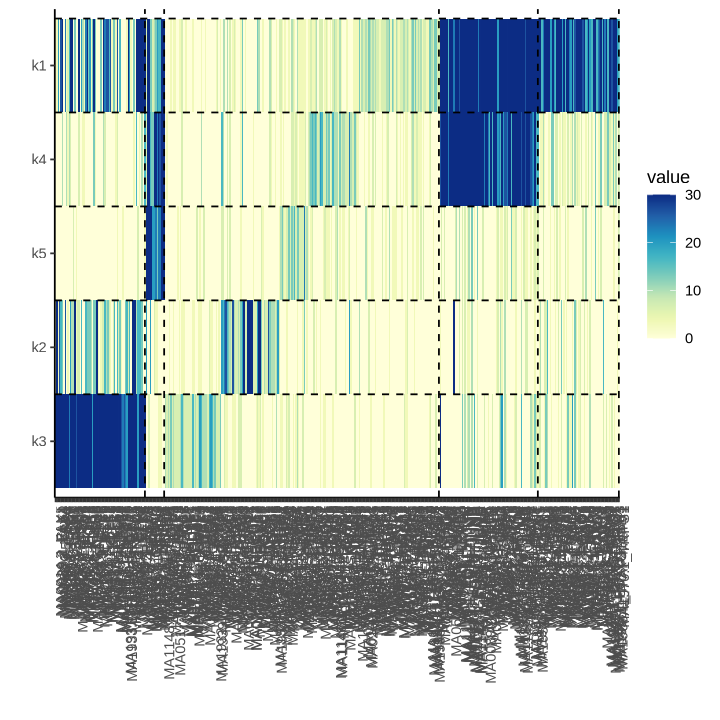

In [119]:
mclass <- paste0("_", c("HLF", "CUX2", "STAT1", "RORA", "ONECUT2", 
            "NR4A1", "SOX4", "NHF4A", "CEBPD", "CEBPA",
            "KLF1", "KLF6", "TEAD2", "BACH1", "NFE2", "SP8", "SP2", 
            "KLF13", "KLF12", "CTCF", "FOSL1", "FOS", "JUN"), "$")

llabel <- grep(paste0(mclass, collapse = "|"), ffile$motif, value = T) %>% unique
labs.row <- unique(ttp$variable) %>% as.character
labs.row[!((labs.row) %in% llabel)] <- ""

t2 <- ttp %>%
ggplot(aes(x = variable, y = celltype, fill = value)) + 
geom_tile() + ylab("") + xlab("") + 
geom_hline(yintercept = seq(1.5, length(unique(ttp$celltype)) + 0.5, by = 1),  # Add lines between rows
           linetype = "dashed", color = "black") +
geom_vline(xintercept = vltp, linetype = "dashed", color = "black") +
theme_classic() + 
# scale_x_discrete(labels = labs.row) + 
theme(axis.text.x = element_text(angle = 90, hjust = 1)) + 
scale_fill_gradientn(colours = colorRampPalette(brewer.pal(n = 8, name = "YlGnBu"))(25))

t2